In [1]:
import numpy as np
import math
import time
from datetime import datetime
import os
import shutil # for copying checkpoint to "last"
from pathlib import Path
import gc

import torch
import torch.nn as nn
import torchvision.transforms as transform

from torch.utils.tensorboard import SummaryWriter
import matplotlib.pylab as plt
%matplotlib inline
from IPython.display import Audio

from utils.utils import param_breakdown

from audioDataLoader.audio_dataset import LatentDatasetConfig, EnCodecLatentDataset, latents_to_audio_simple, efficient_codes_to_latents
from torch.utils.data import DataLoader

import model.gru_audio_model

from transformers import EncodecModel

/home/lonce/miniconda3/envs/basicaudio/lib/python3.12/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
# The syn7wav24_tokens_HFdataset_5 has the following parameters: 
#         ['Full File Name', 'class_name', 'param1', 'param2', 'param3', 'param0', 'audio']
# and the following unique 'class_name' values:
#         Class list: ['ChirpPattern', 'DSApplause', 'DSBugs', 'DSPeepers', 'DSPistons', 'DSWind', 'TokWotalDuet']
# which you can use to filter the full dataset if you only want to train on a subset of sound classes, for example:
#         config.filters = {'class_name': {'DSPistons', 'DSApplause'}}

### Data Params  
<a id="dataparams"></a>

These parameters are saved to file, and serve several purposes:
* The allow other programs to properly evaluate and visualize the trained (and also saved) models,
* Provide a record of the parameters that allow reproducing results. 

In [3]:
resume_checkpoint= None #str(Path("./output/20250817_151624_pistons_2048.16_4.96/"))  # None # 

sourcedatadir = os.path.join(os.getcwd(), '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5' )  # where the data files live
savename="encodectest_TokWotalDuet_splitseqs_sl125_nodes64_6l_size96_nq8"  #just a tag on the output folder 
props={"param1": (0,1)}
#props={"c1": (0, 1), "c2": (0, 1),"c3": (0, 1),"c4": (0, 1),"c5": (0, 1),"c6": (0, 1),"c7": (0, 1),"param_1": (0,1)},
n_q=8
filters= {'class_name': {'TokWotalDuet'}} 

train_split='train_sm'


params = dict(
    # Read/write directory of data & parameter files
    #*************************************
    sample_rate=24000,
    runTimeStamp='{:%Y-%m-%d_%H-%M-%S}'.format(datetime.now()),
    
    datadir = sourcedatadir,
    filters=filters,
    
    savemodel = True,
    savemodel_interval = 10,#10, # in units of epochs
    savemodeldir = os.path.join(os.getcwd(), 'output'), # default saving directory for models and the parameterization

    # Training parameters ----------------------------------------------
    num_epochs = 200, # #20, # of batches_per_epoch of batch_size sequeunce
    batches_per_epoch = 100, #100, 
    batch_size = 100, #100, 
    
    noise=.01,
    seqLen = 125,

    lr = 0.005,
    # parameter names for the Data Loader to search for in the filenames, and the range that maps to [0,1] for training and inference
    # The order specified in this structure will be the order used for inference
    props=props,
    
    # Model parameters
    input_size = 128,
    hiddenSize = 96, #100,
    nLayers = 6,
    codebook_size = 1024, # encodec codebook size
    dropout = 0.1,
    n_q = n_q,                                # Number of codebooks to use
    clamp_val = 15
)

In [4]:
params

{'sample_rate': 24000,
 'runTimeStamp': '2025-09-05_16-39-41',
 'datadir': '/slowdisk/esteban/scratchdata/syntex24/data7wav/syn7wav24_tokens_HFdataset_5',
 'filters': {'class_name': {'TokWotalDuet'}},
 'savemodel': True,
 'savemodel_interval': 10,
 'savemodeldir': '/home/lonce/working/RNN4Codecs/output',
 'num_epochs': 200,
 'batches_per_epoch': 100,
 'batch_size': 100,
 'noise': 0.01,
 'seqLen': 125,
 'lr': 0.005,
 'props': {'param1': (0, 1)},
 'input_size': 128,
 'hiddenSize': 96,
 'nLayers': 6,
 'codebook_size': 1024,
 'dropout': 0.1,
 'n_q': 8,
 'clamp_val': 15}

### Run Params 

In [5]:
sr = params['sample_rate']

log_interval = 1 # units of epochs
visualize_interval = log_interval # units of epochs

#Generation parameters
#*************************************
max_length = params['seqLen']*3  #length of the sequence used to inspect progress in audio plots during training

# Cuda
#*************************************
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
#device='cpu'
device

device(type='cuda', index=0)

In [6]:
# Some utility functions
#*************************************
def time_taken(elapsed):
    """To format time taken in hh:mm:ss. Use with time.monotic()"""
    m, s = divmod(elapsed, 60)
    h, m = divmod(m, 60)
    return "%d:%02d:%02d" % (h, m, s)

def mydate() :
    return (datetime.now().strftime("%Y-%m-%d %H:%M:%S"))



In [7]:

#--- model settings ----#
model_config = model.gru_audio_model.GRUModelConfig (
    input_size = params['input_size'],
    cond_size = len(params['props']),
    hidden_size = params['hiddenSize'],
    num_layers = params['nLayers'],
    codebook_size = params['codebook_size'],  #mu-law quantization levels
    dropout = params['dropout'],
    n_q=params['n_q']
)


# ---- Training Settings ----
data_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
#    encode=True,
    add_noise= False if params['noise'] == 0 else True,   # Whether to add white noise
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters
)

# ---- Generation Settings ----
testdata_config = LatentDatasetConfig(
    dataset_path=params['datadir'],
    sequence_length=params['seqLen'],
    parameter_specs=params['props'],
#    encode=False,
    add_noise= False,                        # no noise for testing and priming
    noise_weight = params['noise'],                           # Desired signal-to-noise ratio (dB)
    codebook_size=params['codebook_size'],
    n_q=params['n_q'],
    clamp_val=params['clamp_val'],
    filters=filters
)

# === Dataset and Loader ===
# Load your EnCodec model (update path as needed)
# this model we put on the GPU (or current device) and pass it to the inference engine (the datasets will have their own copy on the CPU
enc_model = EncodecModel.from_pretrained("facebook/encodec_24khz") # leave on the cpu till we are ready to train+inferece for now
enc_model.eval()

print("✅ Configuration and model loaded")


adataset = EnCodecLatentDataset(data_config, "facebook/encodec_24khz", split=train_split)

train_loader = DataLoader(adataset,
                             batch_size=params['batch_size'],
                             shuffle=True,
                             num_workers=4,
                             drop_last=True)

testdataset = EnCodecLatentDataset(testdata_config, "facebook/encodec_24khz", split='val')
test_loader = DataLoader(testdataset,
                            batch_size=1,
                            shuffle=True,
                            num_workers=4,
                            drop_last=True)
   
# The data "size" is the number of possible sequences the data loader can provide.
# Since the sequences are chosen randomly from the file, the number of possible sequence is the total number of audio samples in the set (minus the ones that start less than sequence length from the end of the files)
print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

✅ Configuration and model loaded
[EnCodecLatentDataset] Filters applied: kept 630 of 4410 rows (14.3%).
Loaded 157500 sequences from 630 files in 'train_sm' split
[EnCodecLatentDataset] Filters applied: kept 21 of 147 rows (14.3%).
Loaded 5250 sequences from 21 files in 'val' split
size of dataset is 157500
no. of batches per epoch is 100
batchsize id  is 100


size of dataset is 157500
no. of batches per epoch is 100
batchsize id  is 100
pvect: tensor([0.0500])
pvect: tensor([0.6500])
inp.shape is torch.Size([125, 128])


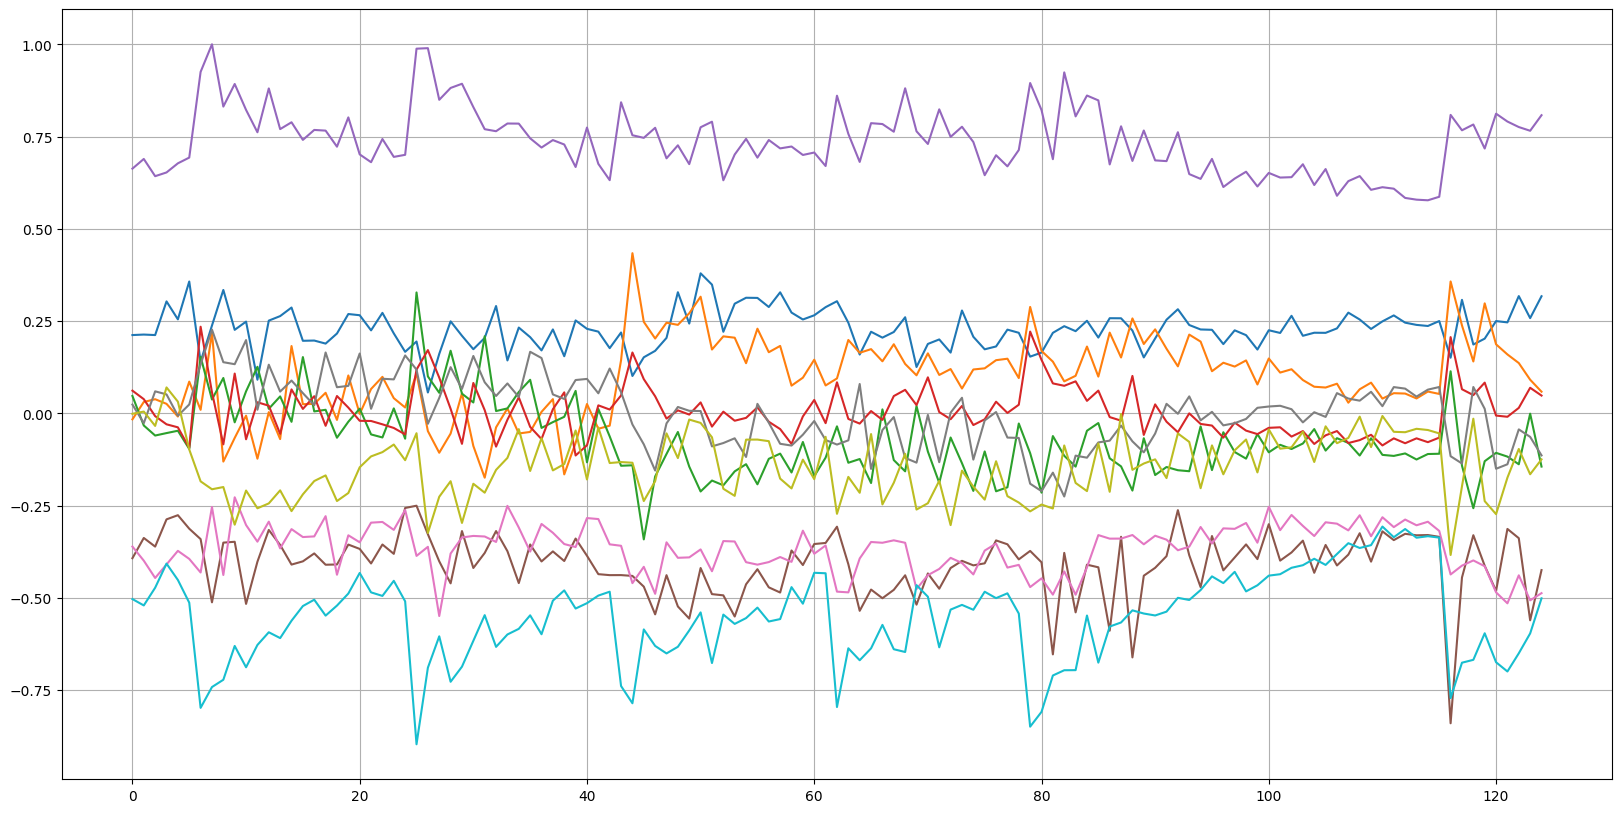

SHAPE: torch.Size([1, 128, 125])


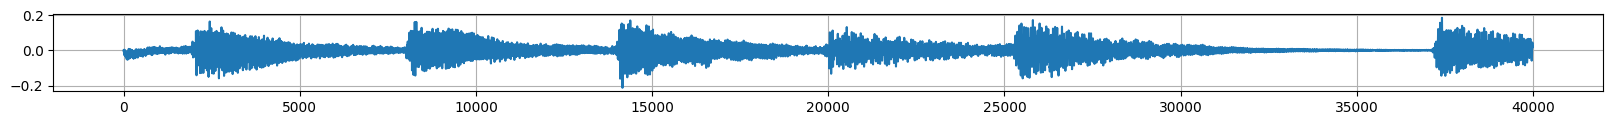

bat num 0 at time 2025-09-05 16:39:43
inp_seq_seq.shape = torch.Size([1, 125, 129])
y_target_seq.shape = torch.Size([1, 125, 8])
conditioning params: tensor([[0.8000],
        [0.8000],
        [0.8000]])  
bat num 1 at time 2025-09-05 16:39:43
inp_seq_seq.shape = torch.Size([1, 125, 129])
y_target_seq.shape = torch.Size([1, 125, 8])
conditioning params: tensor([[0.7000],
        [0.7000],
        [0.7000]])  
finished at 2025-09-05 16:39:43


In [8]:
# just show some stuff 

print("size of dataset is",len(adataset))
print("no. of batches per epoch is", params['batches_per_epoch'])
print("batchsize id  is", params['batch_size'])

samp, target = adataset.rand_sample()  #samp.shape=(T, inputsize+cond_size)

pvect=samp[0, -model_config.cond_size:]
print(f"pvect: {pvect}")
pvect=samp[params['seqLen']-1, -model_config.cond_size:]
print(f"pvect: {pvect}")

inp=samp[:,:-model_config.cond_size]
print(f'inp.shape is {inp.shape}')

# Now grab n=10 random latent components and look at them over time
_, p = inp.shape
# Generate n=10 random indices from 0 to p-1
indices = torch.randperm(p)[:10]
sub_inp = inp[:, indices]
sub_inp.shape


#first print latent sequence
plt.figure(figsize=(20,10)) 
plt.plot(np.arange(len(sub_inp)), sub_inp) #just print one example from the batch
plt.grid()
plt.show()

samp=samp[:, :params['input_size']].T.unsqueeze(0)
print(f'SHAPE: {samp[:,:params['input_size']].shape}')
audiosamps, sr=latents_to_audio_simple(enc_model, samp*params['clamp_val'])
audiosamps=audiosamps[0, 0]

plt.figure(figsize=(20,1)) 
plt.plot(audiosamps) #just print one example from the batch
plt.grid()
plt.show()


n_batches = 1
for bat, (inp_seq, y_target_seq) in enumerate(test_loader):
    print("bat num {} at time {}".format(bat, mydate()))
    print(f"inp_seq_seq.shape = {inp_seq.shape}") 
    print(f"y_target_seq.shape = {y_target_seq.shape}")
    print(f"conditioning params: { inp_seq[ 0,0:3, -len(params['props']):]    }  ")
    if bat >= n_batches :
        break;
print("finished at {}".format(mydate()))

#This is the "rand_samp" plotted above"
Audio(audiosamps, rate=params['sample_rate'])

In [9]:
# Define the training cycle (100% teacher forcing for now)
#*************************************

def train(model,epoch):

 model.train() #put in training mode
 ave_loss_over_steps = 0
 debug_seqs=0

 for batch_num, (inp, target) in enumerate(train_loader):
    debug_seqs += len(inp)
    inp, target = inp.to(device), target.to(device)
    
    hidden = model.init_hidden(params['batch_size'])
    optimizer.zero_grad()
    loss = 0
    
    # Define quantizer weights
    quantizer_weights = [1.0, 0.8, 0.6, 0.4, 0.3, 0.2, 0.15, 0.1][:params['n_q']]
    
    for i in range(params['seqLen']):  # Causal: one time step at a time
        outputs, hidden = model(inp[:,i,:], hidden, params['batch_size'])
        
        # Per-quantizer weighted loss (keeping the loop for flexibility)
        for j in range(params['n_q']):
            quantizer_loss = criterion(outputs[j], target[:,i,j])
            loss += quantizer_weights[j] * quantizer_loss
    
    # Normalize by sequence length and total weight
    total_weight = sum(quantizer_weights)
    loss = loss / (params['seqLen'] * total_weight)
    
    loss.backward()
    optimizer.step()
    
    ave_loss_per_sample = loss.item()/params['seqLen']   #over each minibatch
    ave_loss_over_steps += ave_loss_per_sample
    
    if batch_num>=(params['batches_per_epoch']-1):
     break

 print(f"Finished epoch number {epoch} with a total of {debug_seqs} debug_seqs")


 if (epoch+1) % log_interval == 0:
     print(f" time: {datetime.now()}, epoch {epoch+1},  Loss: {ave_loss_per_sample:.4f}")
     list_of_losses.append(ave_loss_per_sample)
     writer.add_scalar("Loss/train", ave_loss_per_sample, epoch+1)

 if (epoch+1) % visualize_interval == 0:

     # these two lines address a resource management issues with temporary directories ...  I think....
     torch.cuda.empty_cache()  # if using GPU
     gc.collect()

     result = newgen(model,max_length)
     print(f'plot the audio which has shape {result.shape}')
     plt.figure(figsize=(20,1))
     plt.plot(np.arange(len(result)), result) #just print one example from the batch
     plt.show()
     model.train() #put model back to training mode


 # overwrite the last, and save a numbered checkpoint
 if (epoch + 1) % params['savemodel_interval'] == 0:
    checkpoint_data = {
        'epoch': epoch+1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict()
    }
    
    # Save numbered checkpoint
    numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
    torch.save(checkpoint_data, numbered_path)
    
    # Copy to "last" (much faster than saving twice)
    last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    shutil.copy2(numbered_path, last_path)
    
    print(f"Saved checkpoint at epoch {epoch+1}")

In [10]:
# ---- Create Output Folders ----
if resume_checkpoint != None:
    out_dir = resume_checkpoint
else:
    run_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = os.path.join(params['savemodeldir'], run_timestamp + "_"+savename)
    os.makedirs(out_dir, exist_ok=True)

    os.makedirs(out_dir, exist_ok=True)
    os.makedirs(f"{out_dir}/checkpoints", exist_ok=True)
    os.makedirs(f"{out_dir}/tensorboard", exist_ok=True)


# ---- Save Config ----
#machine readable
torch.save({
    "model_config": model_config,
    "data_config": data_config
}, f"{out_dir}/config.pt")

#human readable
with open(f"{out_dir}/config.txt", "w") as f: 
    f.write("params = " + repr(params) + "\\n")
    f.write("model_config = " + repr(model_config) + "\\n")
    f.write("data_config = " + repr(data_config) + "\\n")

In [11]:
# this is for visualizing learning be showing one example of a generated sequence.
# the model is warmed up with a random sequence from the data set and it's corresponding param vector
from inference import run_inference

def newgen(model,max_length):
    p_inp, _ = next(iter(test_loader)) # don't need targets
    
    x = p_inp[:, :, :params['input_size']].squeeze(0) # no batch
    c = p_inp[:, 0, -model_config.cond_size:]
    c = c.repeat(max_length, 1) 

    print(f'About to call inference with p_inp.shape = {p_inp.shape}, x.shape = {x.shape}, and c.shape = {c.shape}')
    print(f'About to call inference with p_inp.device = {p_inp.device}, x.device = {x.device}, and c.device = {c.device}')

    gen, sr = run_inference(model, enc_model, c.to(device), x.to(device), params['clamp_val'], top_n=3, temperature=1.0, include_warmup_audio=True)
    
    return gen


### Load the model 

In [12]:

rnn = model.gru_audio_model.RNN(model_config).to(device)
    
optimizer = torch.optim.Adam(rnn.parameters(), lr=params['lr'])
criterion = nn.CrossEntropyLoss()

start_epoch=0

if resume_checkpoint:
    checkpoint_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
    assert os.path.exists(checkpoint_path), f"File {checkpoint_path} does not exist"
    checkpoint = torch.load(checkpoint_path)
    rnn.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumed from checkpoint at epoch {start_epoch}")

writer = SummaryWriter(log_dir=f"{out_dir}/tensorboard")

In [13]:
num_trainable_params = sum(p.numel() for p in rnn.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_trainable_params}")

bd = param_breakdown(rnn, trainable_only=True) #prints out a breakdown of the parameter counts per layter
# pretty print
print(f"latent_proj: {bd['latent_proj']:,}")
print(f"cond_proj:   {bd['cond_proj']:,}")
print(f"GRU total:   {bd['gru_total']:,}")
for k, v in bd['gru_layers'].items():
    print(f"  {k}: {v:,}")
print("Decoders (per head):")
for i, n in enumerate(bd['decoders']):
    print(f"  decoder[{i}]: {n:,}")
print(f"Decoders total: {bd['decoders_total']:,}")
print(f"Model total:    {bd['model_total']:,}")

Total trainable parameters: 1136144
latent_proj: 6,192
cond_proj:   96
GRU total:   335,232
  l0/fwd: 55,872
  l1/fwd: 55,872
  l2/fwd: 55,872
  l3/fwd: 55,872
  l4/fwd: 55,872
  l5/fwd: 55,872
Decoders (per head):
  decoder[0]: 99,328
  decoder[1]: 99,328
  decoder[2]: 99,328
  decoder[3]: 99,328
  decoder[4]: 99,328
  decoder[5]: 99,328
  decoder[6]: 99,328
  decoder[7]: 99,328
Decoders total: 794,624
Model total:    1,136,144


2025-09-05 16:39:43 Starting training...
Finished epoch number 0 with a total of 10000 debug_seqs
 time: 2025-09-05 16:40:04.072070, epoch 1,  Loss: 0.0360
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 1.00. Converting to audio...
Inference complete - encoding time = 0.08.
plot the audio which has shape (160000,)


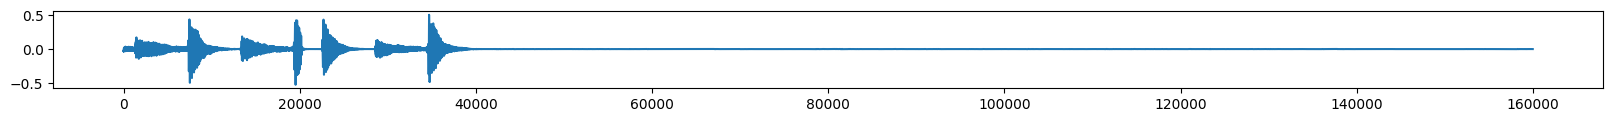

Finished epoch number 1 with a total of 10000 debug_seqs
 time: 2025-09-05 16:40:25.694888, epoch 2,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


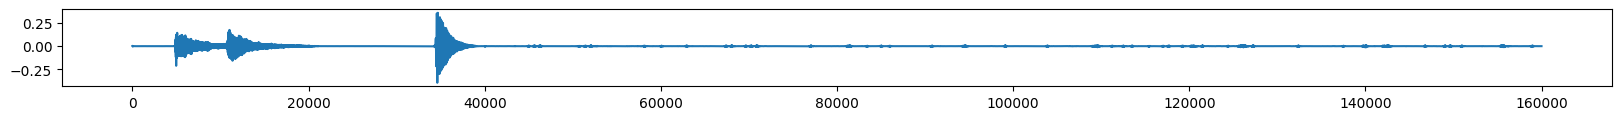

Finished epoch number 2 with a total of 10000 debug_seqs
 time: 2025-09-05 16:40:47.309652, epoch 3,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


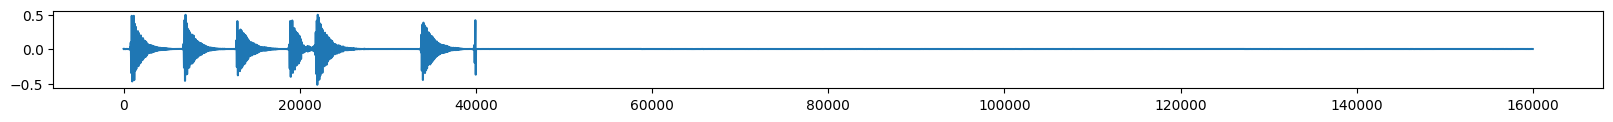

Finished epoch number 3 with a total of 10000 debug_seqs
 time: 2025-09-05 16:41:08.800209, epoch 4,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


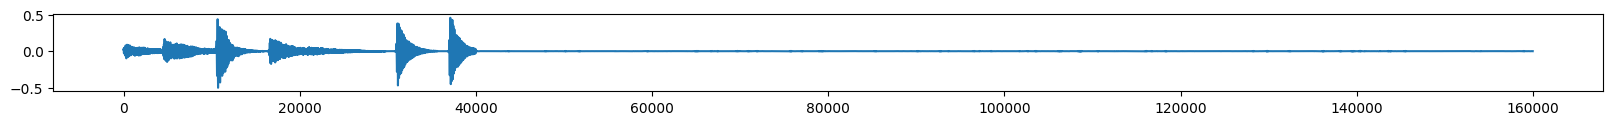

Finished epoch number 4 with a total of 10000 debug_seqs
 time: 2025-09-05 16:41:30.413587, epoch 5,  Loss: 0.0356
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


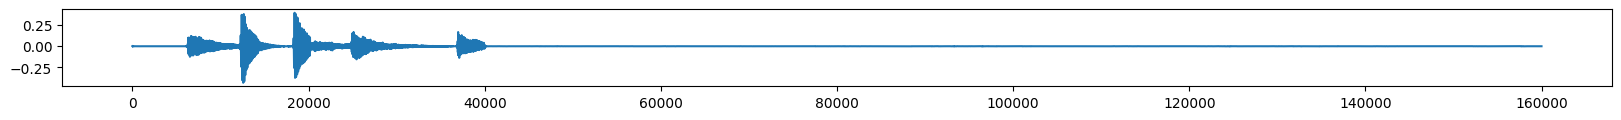

Finished epoch number 5 with a total of 10000 debug_seqs
 time: 2025-09-05 16:41:52.005486, epoch 6,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


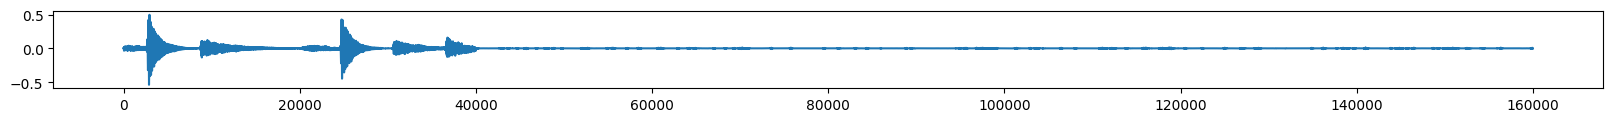

Finished epoch number 6 with a total of 10000 debug_seqs
 time: 2025-09-05 16:42:13.523786, epoch 7,  Loss: 0.0352
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


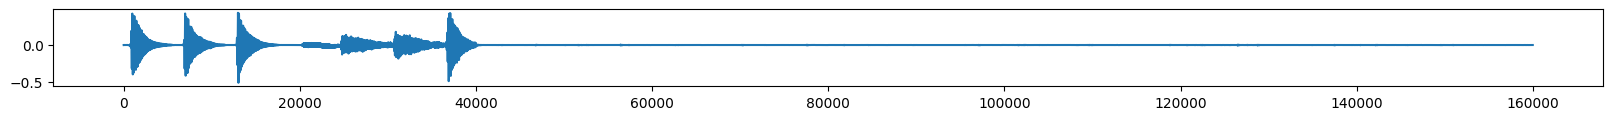

Finished epoch number 7 with a total of 10000 debug_seqs
 time: 2025-09-05 16:42:35.081905, epoch 8,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


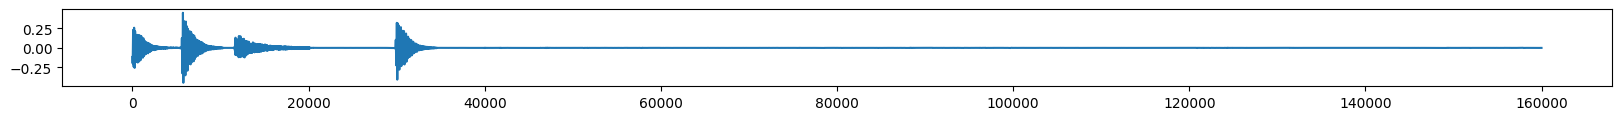

Finished epoch number 8 with a total of 10000 debug_seqs
 time: 2025-09-05 16:42:56.560666, epoch 9,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


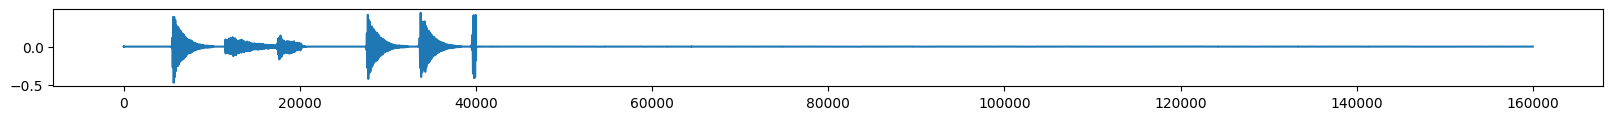

Finished epoch number 9 with a total of 10000 debug_seqs
 time: 2025-09-05 16:43:18.022897, epoch 10,  Loss: 0.0360
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


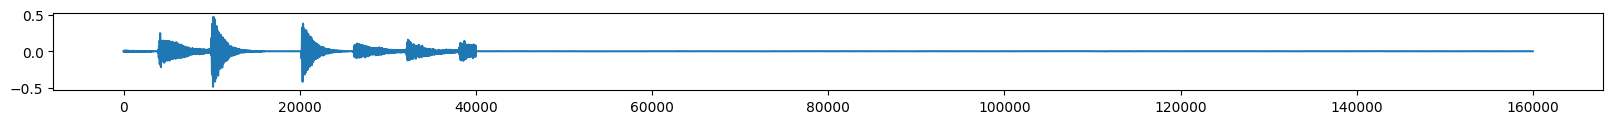

Saved checkpoint at epoch 10
Finished epoch number 10 with a total of 10000 debug_seqs
 time: 2025-09-05 16:43:39.470867, epoch 11,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


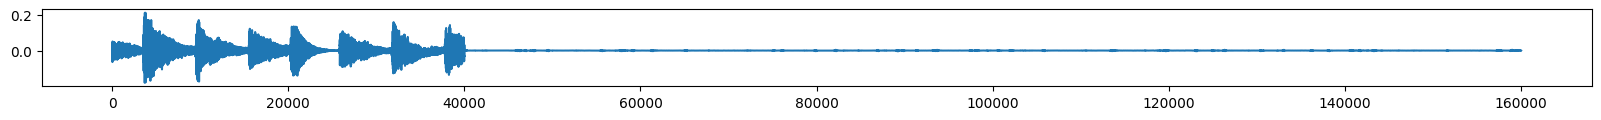

Finished epoch number 11 with a total of 10000 debug_seqs
 time: 2025-09-05 16:44:01.132558, epoch 12,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


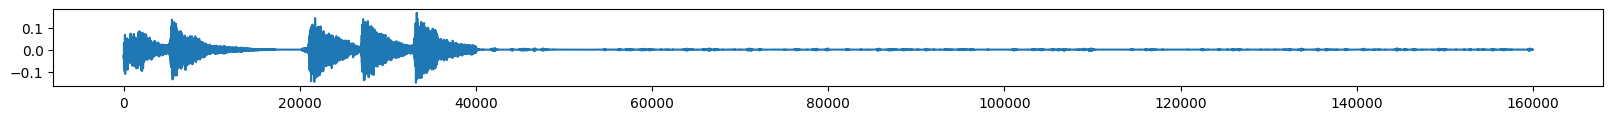

Finished epoch number 12 with a total of 10000 debug_seqs
 time: 2025-09-05 16:44:22.738614, epoch 13,  Loss: 0.0352
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


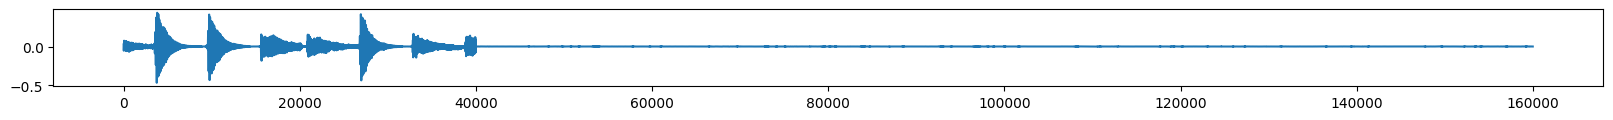

Finished epoch number 13 with a total of 10000 debug_seqs
 time: 2025-09-05 16:44:44.403559, epoch 14,  Loss: 0.0356
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.92. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


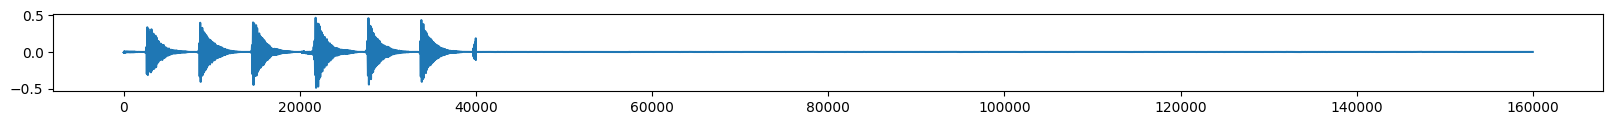

Finished epoch number 14 with a total of 10000 debug_seqs
 time: 2025-09-05 16:45:05.949790, epoch 15,  Loss: 0.0354
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


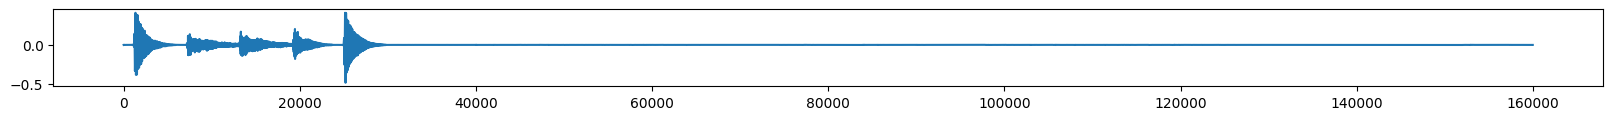

Finished epoch number 15 with a total of 10000 debug_seqs
 time: 2025-09-05 16:45:27.478820, epoch 16,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


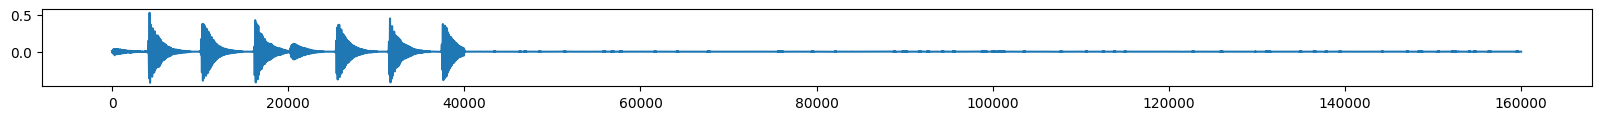

Finished epoch number 16 with a total of 10000 debug_seqs
 time: 2025-09-05 16:45:49.176480, epoch 17,  Loss: 0.0353
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


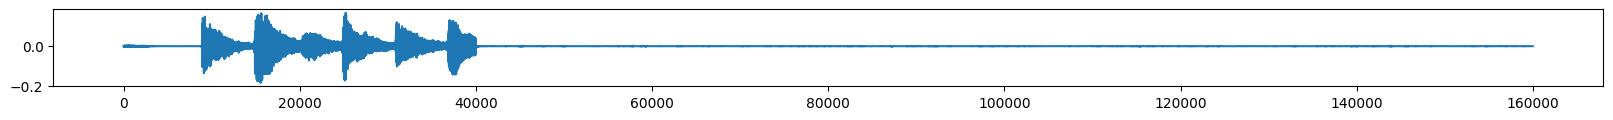

Finished epoch number 17 with a total of 10000 debug_seqs
 time: 2025-09-05 16:46:10.798460, epoch 18,  Loss: 0.0356
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


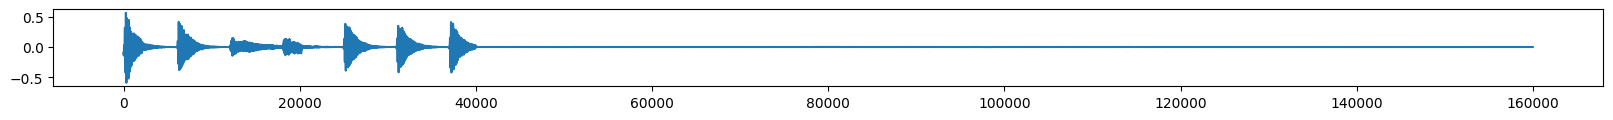

Finished epoch number 18 with a total of 10000 debug_seqs
 time: 2025-09-05 16:46:32.429442, epoch 19,  Loss: 0.0349
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.92. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


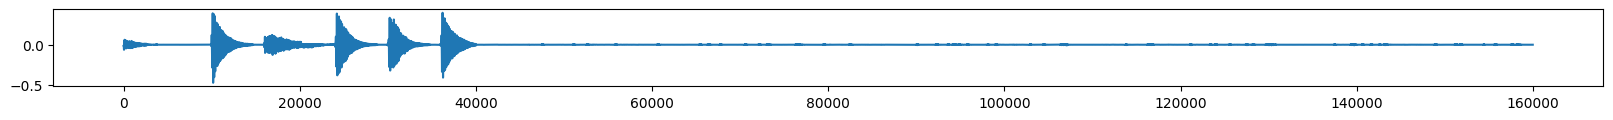

Finished epoch number 19 with a total of 10000 debug_seqs
 time: 2025-09-05 16:46:54.099340, epoch 20,  Loss: 0.0353
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


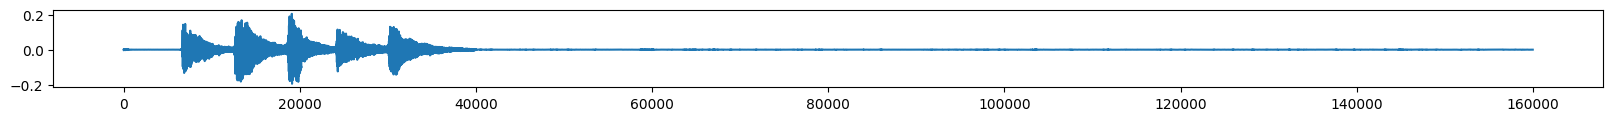

Saved checkpoint at epoch 20
Finished epoch number 20 with a total of 10000 debug_seqs
 time: 2025-09-05 16:47:15.809641, epoch 21,  Loss: 0.0356
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


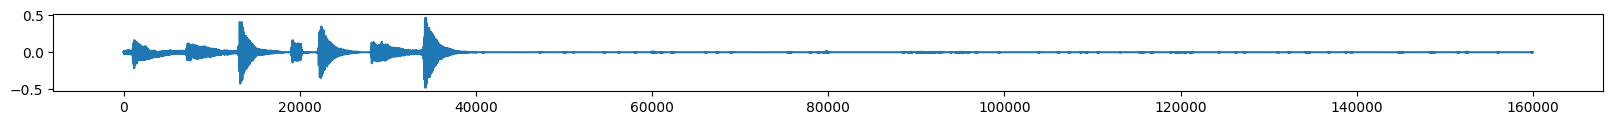

Finished epoch number 21 with a total of 10000 debug_seqs
 time: 2025-09-05 16:47:37.571700, epoch 22,  Loss: 0.0352
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


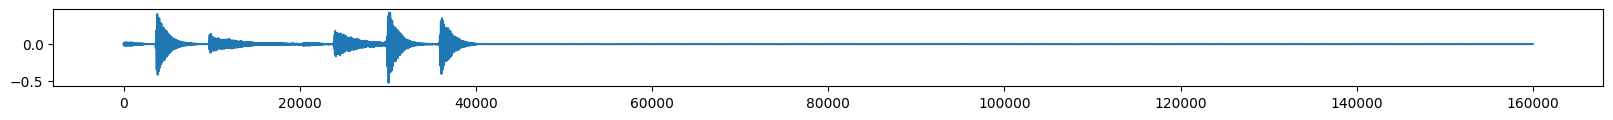

Finished epoch number 22 with a total of 10000 debug_seqs
 time: 2025-09-05 16:47:59.189751, epoch 23,  Loss: 0.0363
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


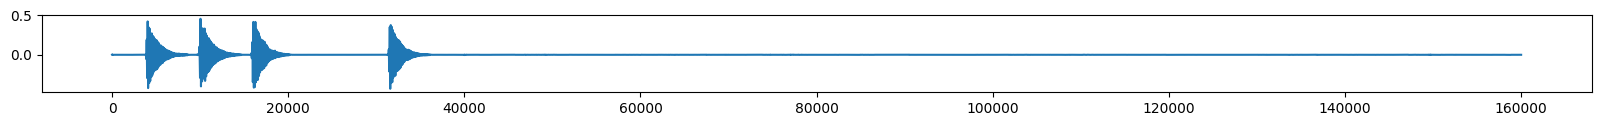

Finished epoch number 23 with a total of 10000 debug_seqs
 time: 2025-09-05 16:48:20.838769, epoch 24,  Loss: 0.0363
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


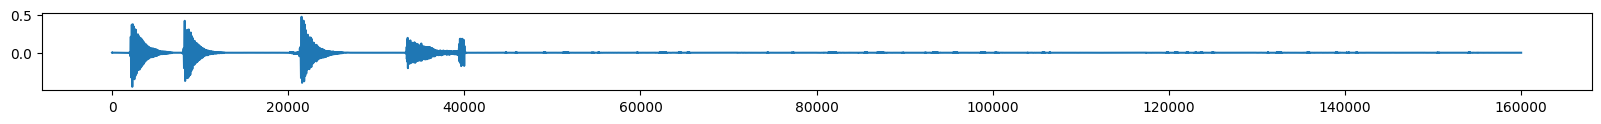

Finished epoch number 24 with a total of 10000 debug_seqs
 time: 2025-09-05 16:48:42.395640, epoch 25,  Loss: 0.0353
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


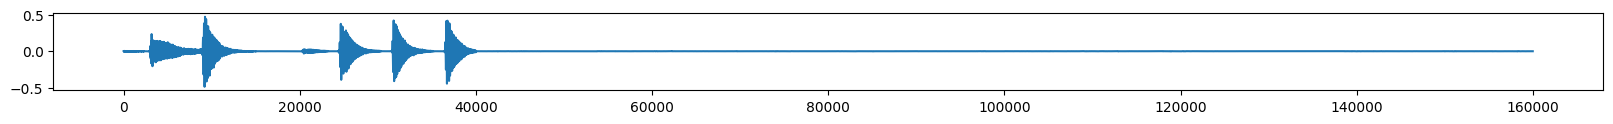

Finished epoch number 25 with a total of 10000 debug_seqs
 time: 2025-09-05 16:49:04.070433, epoch 26,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


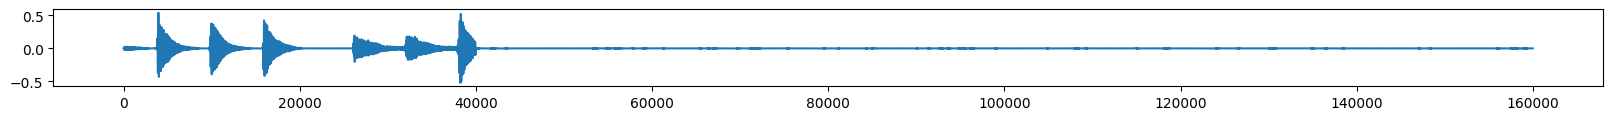

Finished epoch number 26 with a total of 10000 debug_seqs
 time: 2025-09-05 16:49:25.758144, epoch 27,  Loss: 0.0348
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


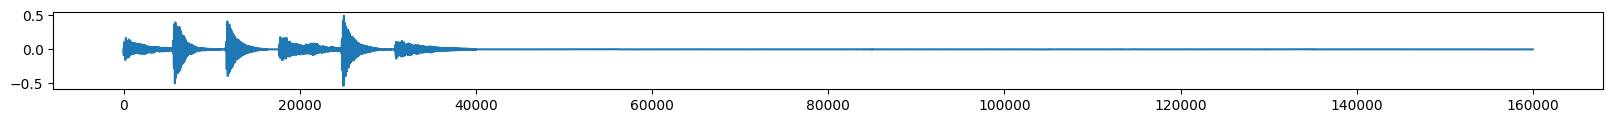

Finished epoch number 27 with a total of 10000 debug_seqs
 time: 2025-09-05 16:49:47.365191, epoch 28,  Loss: 0.0349
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


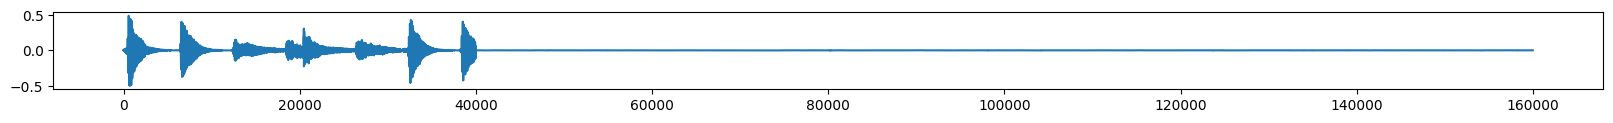

Finished epoch number 28 with a total of 10000 debug_seqs
 time: 2025-09-05 16:50:09.134606, epoch 29,  Loss: 0.0357
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


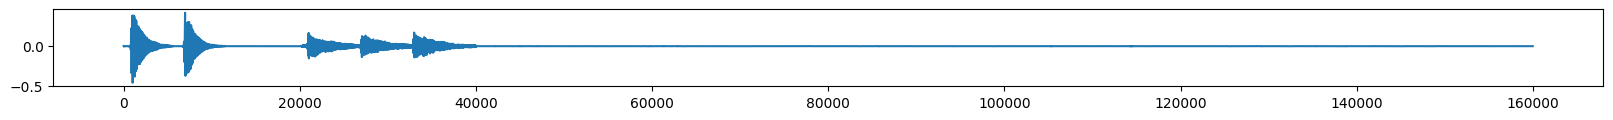

Finished epoch number 29 with a total of 10000 debug_seqs
 time: 2025-09-05 16:50:30.844127, epoch 30,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.93. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


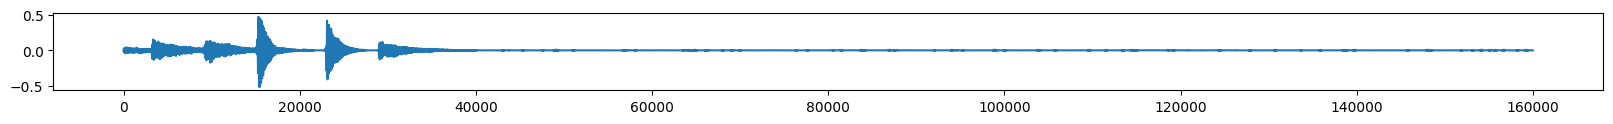

Saved checkpoint at epoch 30
Finished epoch number 30 with a total of 10000 debug_seqs
 time: 2025-09-05 16:50:52.677694, epoch 31,  Loss: 0.0344
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


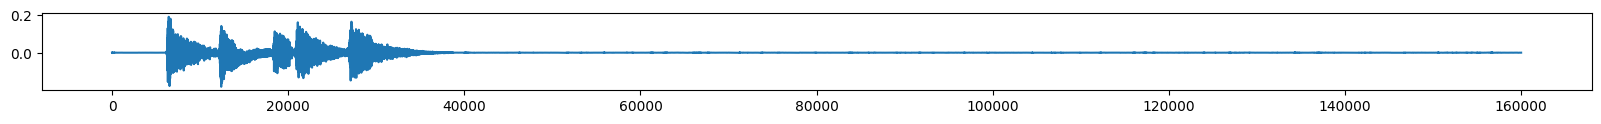

Finished epoch number 31 with a total of 10000 debug_seqs
 time: 2025-09-05 16:51:14.252495, epoch 32,  Loss: 0.0347
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


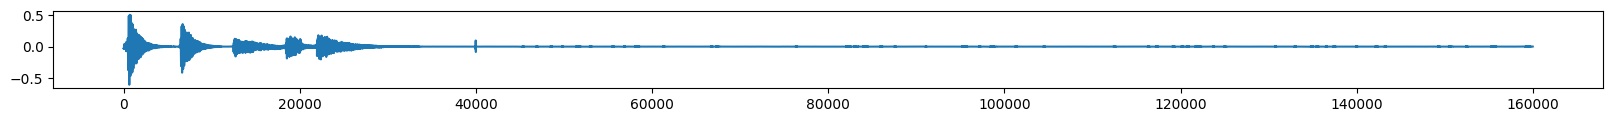

Finished epoch number 32 with a total of 10000 debug_seqs
 time: 2025-09-05 16:51:35.847176, epoch 33,  Loss: 0.0365
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


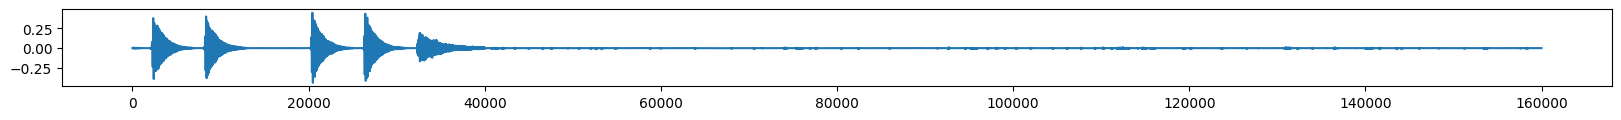

Finished epoch number 33 with a total of 10000 debug_seqs
 time: 2025-09-05 16:51:57.427365, epoch 34,  Loss: 0.0354
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


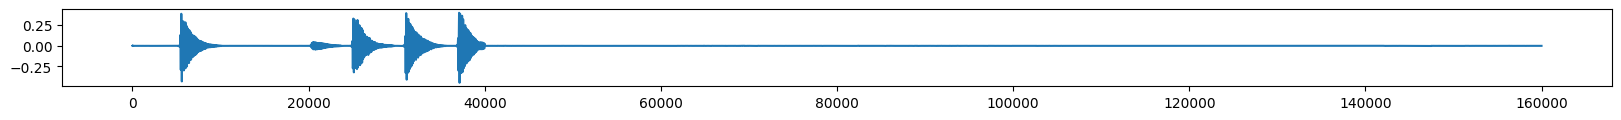

Finished epoch number 34 with a total of 10000 debug_seqs
 time: 2025-09-05 16:52:19.101341, epoch 35,  Loss: 0.0354
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


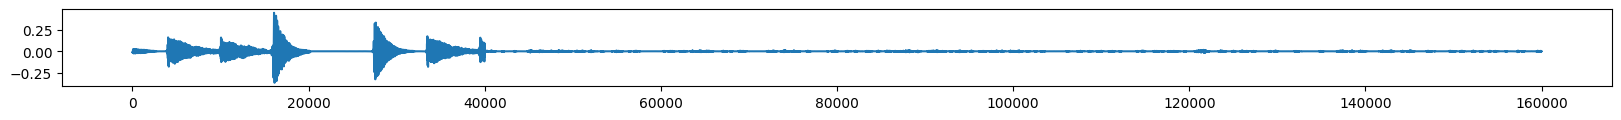

Finished epoch number 35 with a total of 10000 debug_seqs
 time: 2025-09-05 16:52:40.707807, epoch 36,  Loss: 0.0359
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


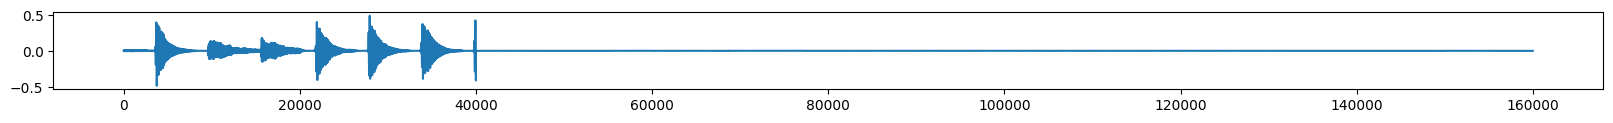

Finished epoch number 36 with a total of 10000 debug_seqs
 time: 2025-09-05 16:53:02.296789, epoch 37,  Loss: 0.0357
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


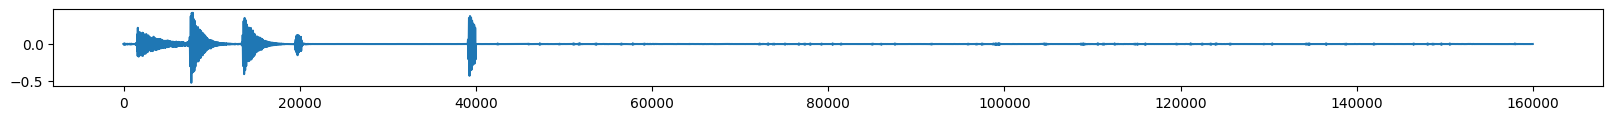

Finished epoch number 37 with a total of 10000 debug_seqs
 time: 2025-09-05 16:53:23.890666, epoch 38,  Loss: 0.0357
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


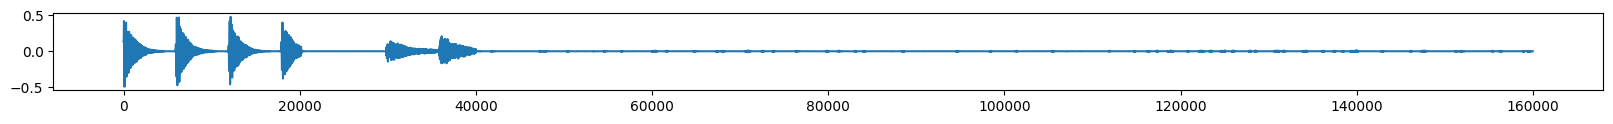

Finished epoch number 38 with a total of 10000 debug_seqs
 time: 2025-09-05 16:53:45.443740, epoch 39,  Loss: 0.0360
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


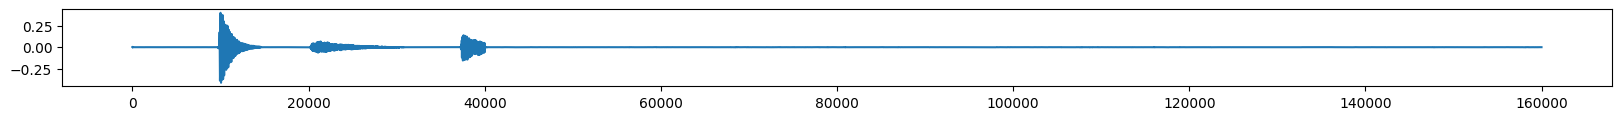

Finished epoch number 39 with a total of 10000 debug_seqs
 time: 2025-09-05 16:54:06.997839, epoch 40,  Loss: 0.0360
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


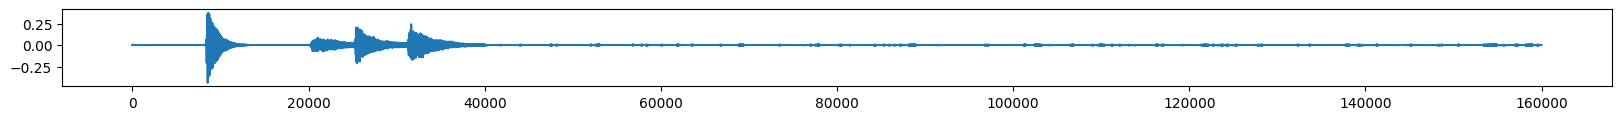

Saved checkpoint at epoch 40
Finished epoch number 40 with a total of 10000 debug_seqs
 time: 2025-09-05 16:54:28.572053, epoch 41,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


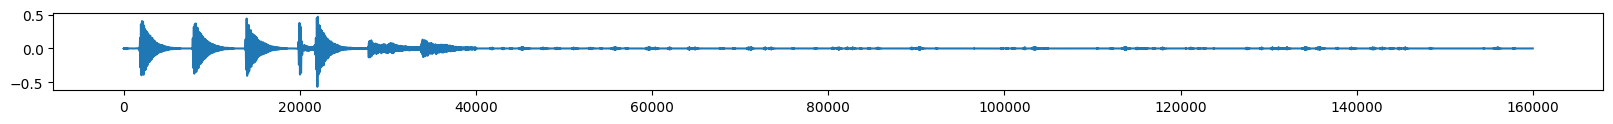

Finished epoch number 41 with a total of 10000 debug_seqs
 time: 2025-09-05 16:54:50.310122, epoch 42,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


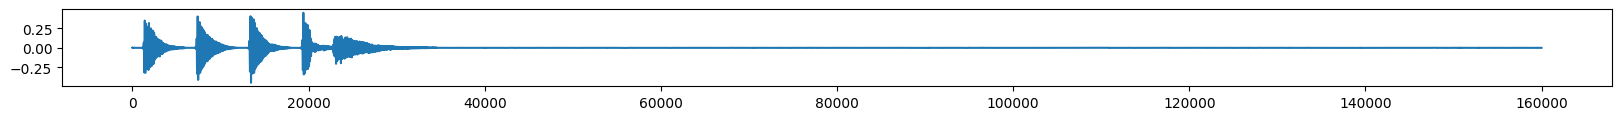

Finished epoch number 42 with a total of 10000 debug_seqs
 time: 2025-09-05 16:55:11.902572, epoch 43,  Loss: 0.0363
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


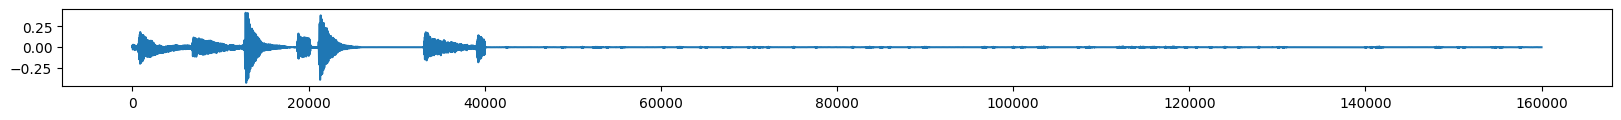

Finished epoch number 43 with a total of 10000 debug_seqs
 time: 2025-09-05 16:55:33.496488, epoch 44,  Loss: 0.0356
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.92. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


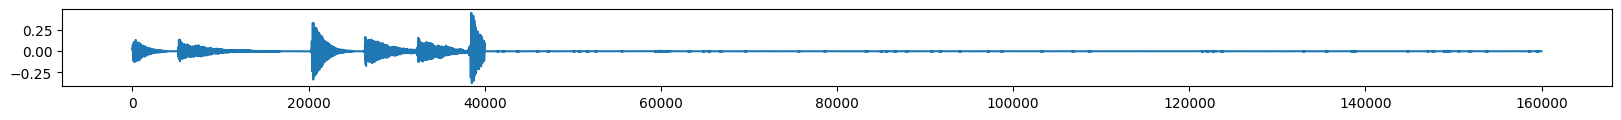

Finished epoch number 44 with a total of 10000 debug_seqs
 time: 2025-09-05 16:55:55.043944, epoch 45,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


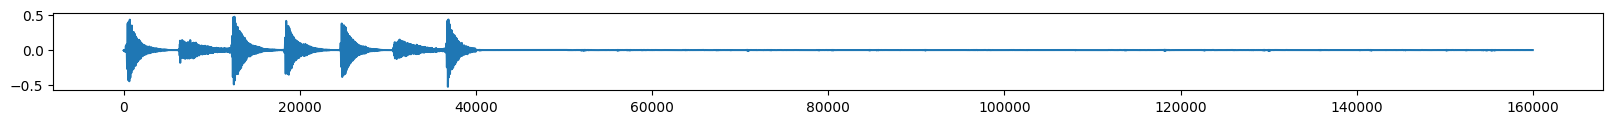

Finished epoch number 45 with a total of 10000 debug_seqs
 time: 2025-09-05 16:56:16.624768, epoch 46,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


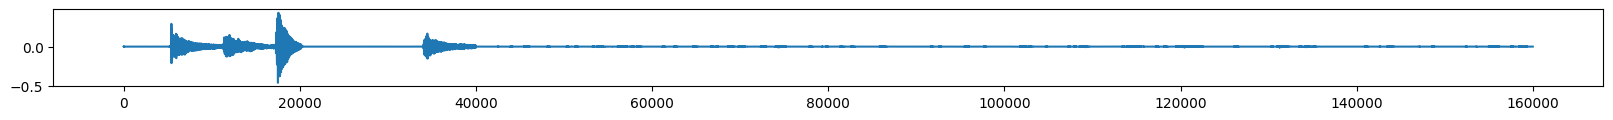

Finished epoch number 46 with a total of 10000 debug_seqs
 time: 2025-09-05 16:56:38.295863, epoch 47,  Loss: 0.0366
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


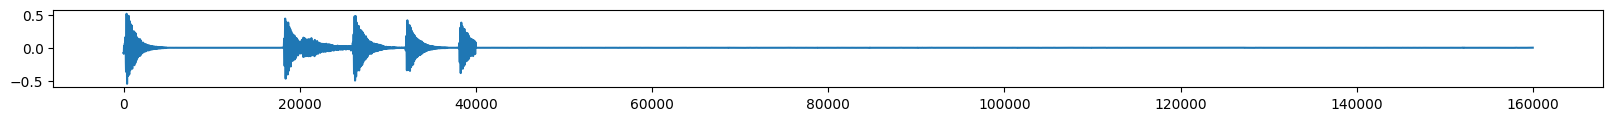

Finished epoch number 47 with a total of 10000 debug_seqs
 time: 2025-09-05 16:56:59.808576, epoch 48,  Loss: 0.0353
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


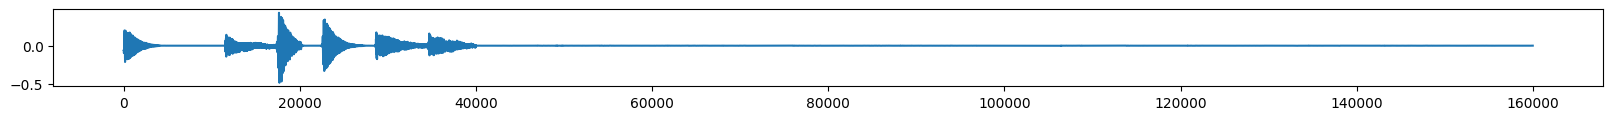

Finished epoch number 48 with a total of 10000 debug_seqs
 time: 2025-09-05 16:57:21.366483, epoch 49,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


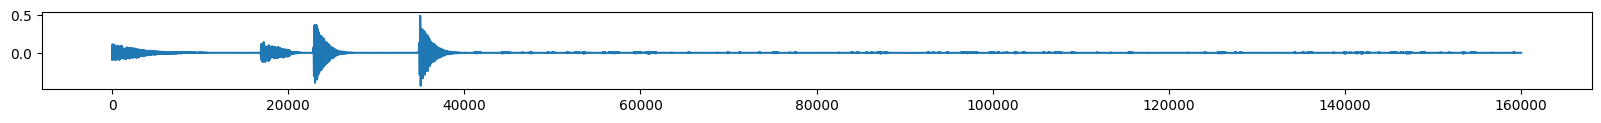

Finished epoch number 49 with a total of 10000 debug_seqs
 time: 2025-09-05 16:57:42.953011, epoch 50,  Loss: 0.0362
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


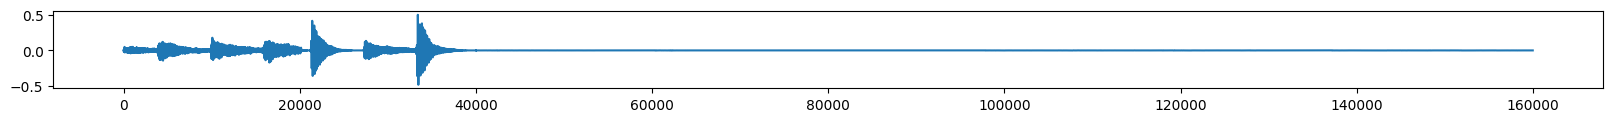

Saved checkpoint at epoch 50
Finished epoch number 50 with a total of 10000 debug_seqs
 time: 2025-09-05 16:58:04.571843, epoch 51,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


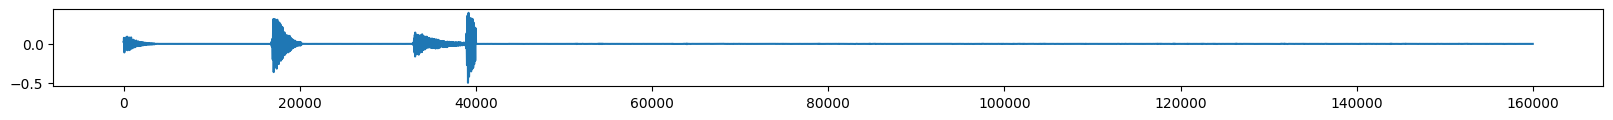

Finished epoch number 51 with a total of 10000 debug_seqs
 time: 2025-09-05 16:58:26.137778, epoch 52,  Loss: 0.0361
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


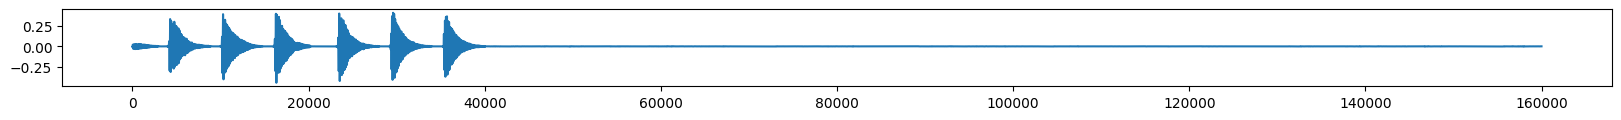

Finished epoch number 52 with a total of 10000 debug_seqs
 time: 2025-09-05 16:58:47.666279, epoch 53,  Loss: 0.0353
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


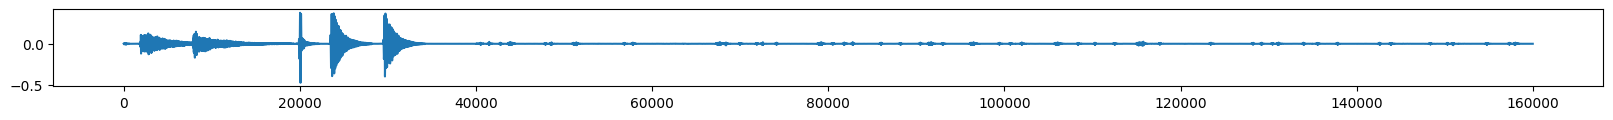

Finished epoch number 53 with a total of 10000 debug_seqs
 time: 2025-09-05 16:59:09.138316, epoch 54,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


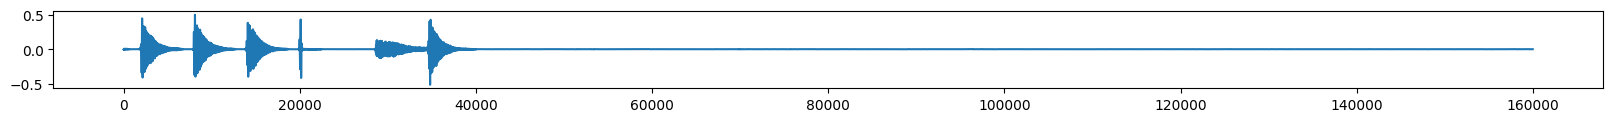

Finished epoch number 54 with a total of 10000 debug_seqs
 time: 2025-09-05 16:59:30.687849, epoch 55,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


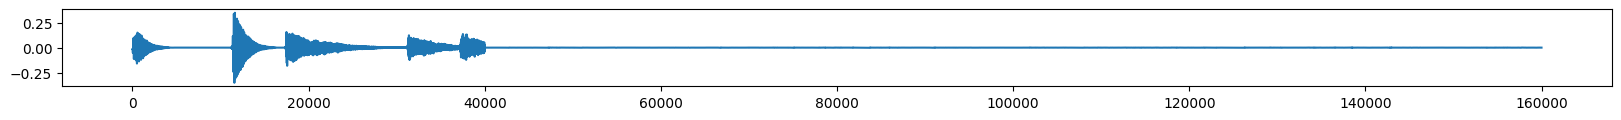

Finished epoch number 55 with a total of 10000 debug_seqs
 time: 2025-09-05 16:59:52.281921, epoch 56,  Loss: 0.0353
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


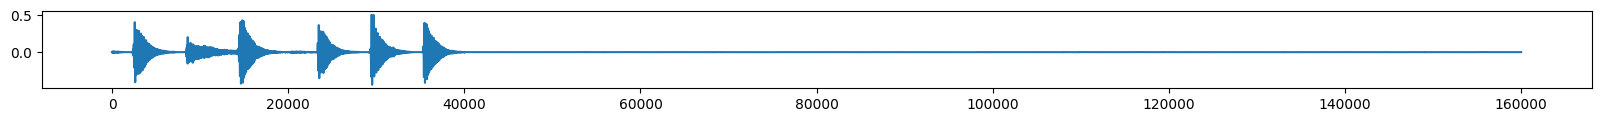

Finished epoch number 56 with a total of 10000 debug_seqs
 time: 2025-09-05 17:00:13.756130, epoch 57,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


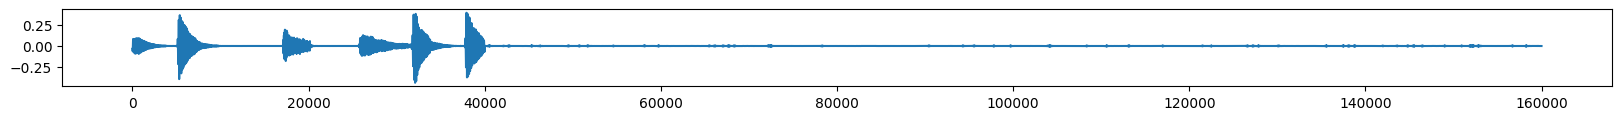

Finished epoch number 57 with a total of 10000 debug_seqs
 time: 2025-09-05 17:00:35.233502, epoch 58,  Loss: 0.0357
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


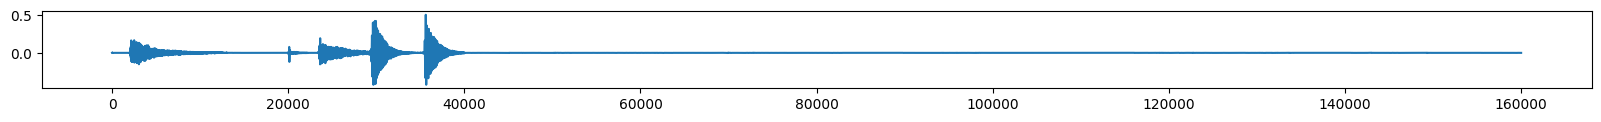

Finished epoch number 58 with a total of 10000 debug_seqs
 time: 2025-09-05 17:00:56.722881, epoch 59,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


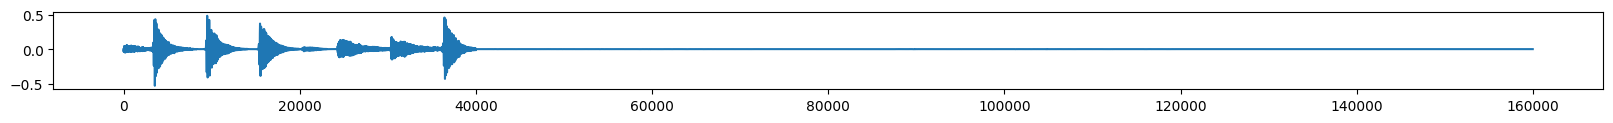

Finished epoch number 59 with a total of 10000 debug_seqs
 time: 2025-09-05 17:01:18.219852, epoch 60,  Loss: 0.0363
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


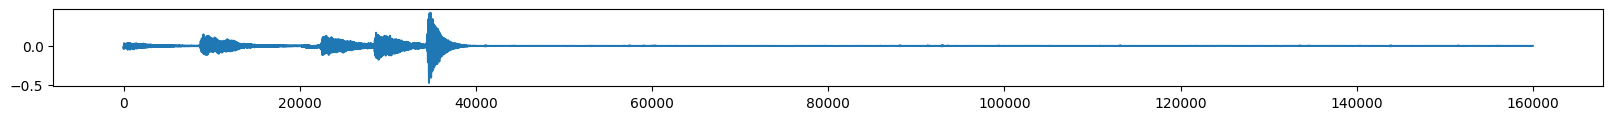

Saved checkpoint at epoch 60
Finished epoch number 60 with a total of 10000 debug_seqs
 time: 2025-09-05 17:01:39.714833, epoch 61,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


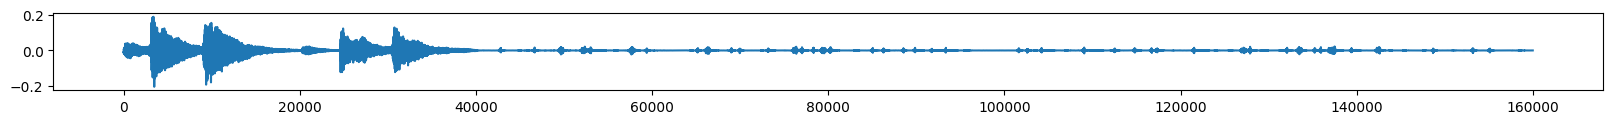

Finished epoch number 61 with a total of 10000 debug_seqs
 time: 2025-09-05 17:02:01.216962, epoch 62,  Loss: 0.0362
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


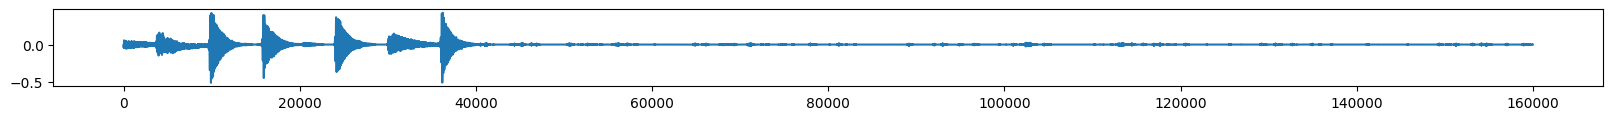

Finished epoch number 62 with a total of 10000 debug_seqs
 time: 2025-09-05 17:02:22.694626, epoch 63,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


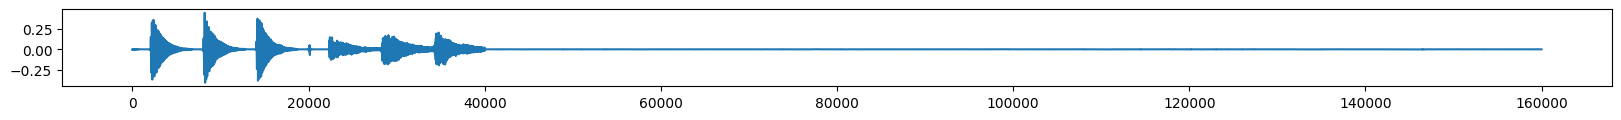

Finished epoch number 63 with a total of 10000 debug_seqs
 time: 2025-09-05 17:02:44.191578, epoch 64,  Loss: 0.0362
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


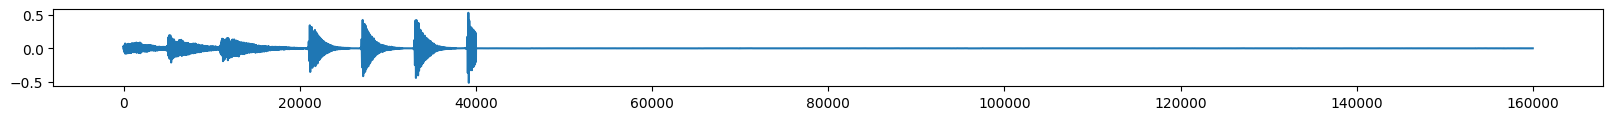

Finished epoch number 64 with a total of 10000 debug_seqs
 time: 2025-09-05 17:03:05.740730, epoch 65,  Loss: 0.0356
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


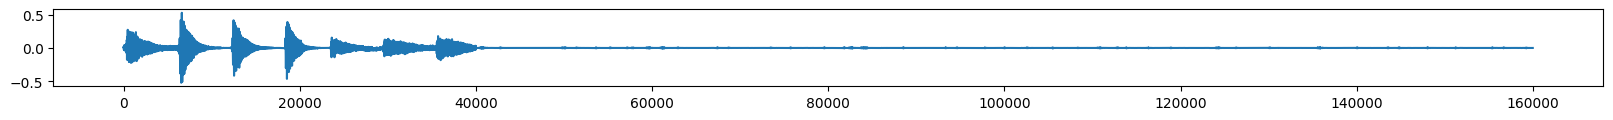

Finished epoch number 65 with a total of 10000 debug_seqs
 time: 2025-09-05 17:03:27.270705, epoch 66,  Loss: 0.0368
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


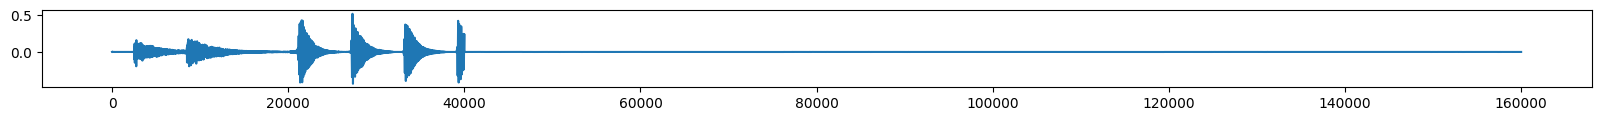

Finished epoch number 66 with a total of 10000 debug_seqs
 time: 2025-09-05 17:03:48.899779, epoch 67,  Loss: 0.0359
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


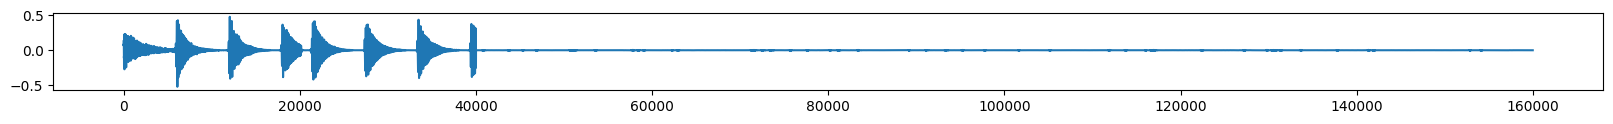

Finished epoch number 67 with a total of 10000 debug_seqs
 time: 2025-09-05 17:04:10.408488, epoch 68,  Loss: 0.0363
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


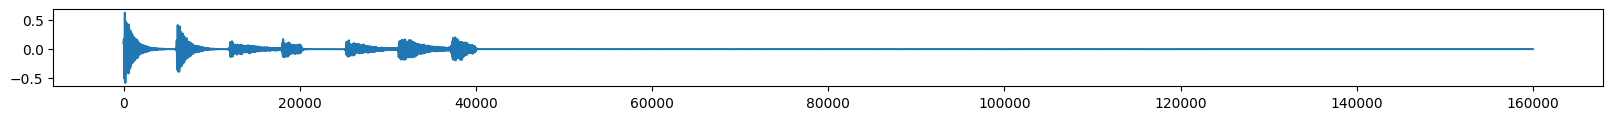

Finished epoch number 68 with a total of 10000 debug_seqs
 time: 2025-09-05 17:04:31.880680, epoch 69,  Loss: 0.0354
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


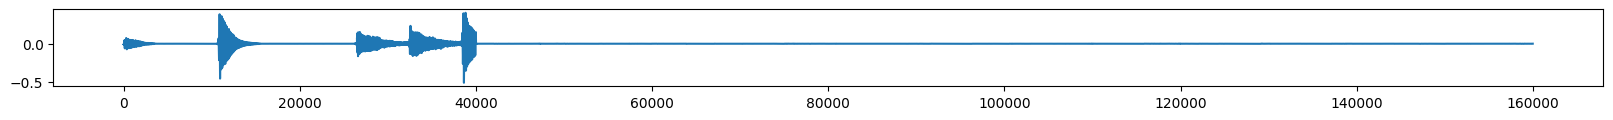

Finished epoch number 69 with a total of 10000 debug_seqs
 time: 2025-09-05 17:04:53.361614, epoch 70,  Loss: 0.0357
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


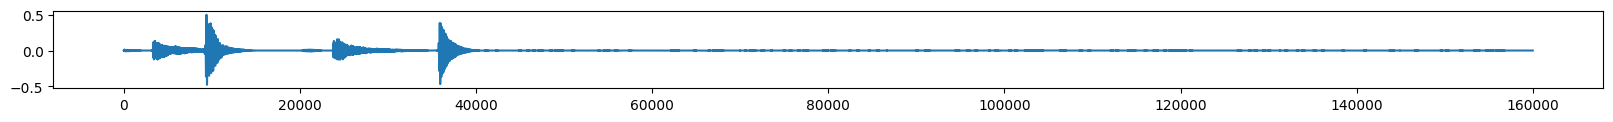

Saved checkpoint at epoch 70
Finished epoch number 70 with a total of 10000 debug_seqs
 time: 2025-09-05 17:05:14.939495, epoch 71,  Loss: 0.0352
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


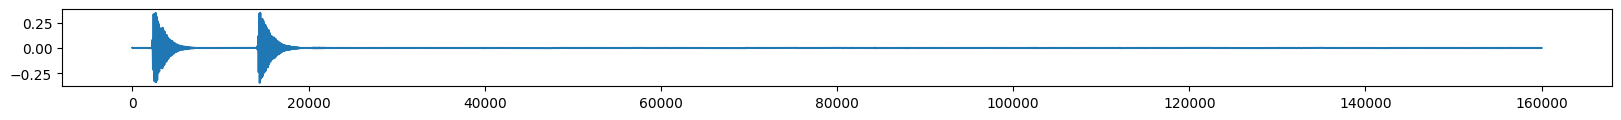

Finished epoch number 71 with a total of 10000 debug_seqs
 time: 2025-09-05 17:05:36.438492, epoch 72,  Loss: 0.0352
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


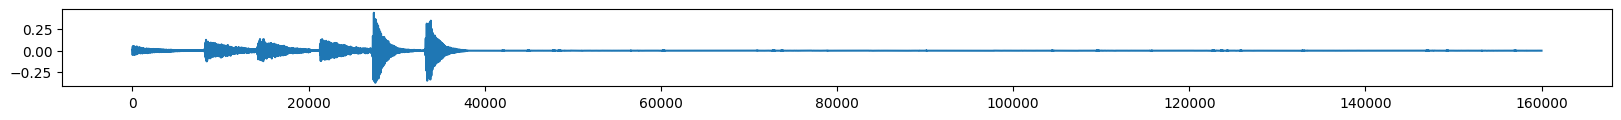

Finished epoch number 72 with a total of 10000 debug_seqs
 time: 2025-09-05 17:05:57.925459, epoch 73,  Loss: 0.0357
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


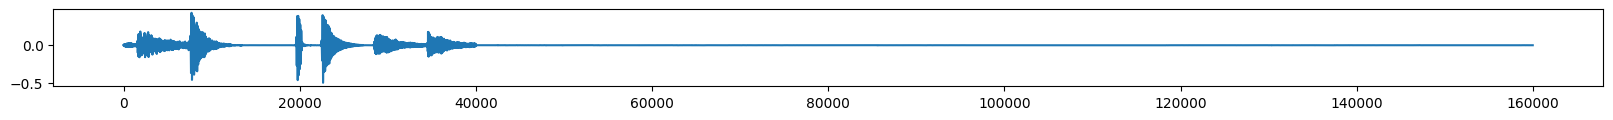

Finished epoch number 73 with a total of 10000 debug_seqs
 time: 2025-09-05 17:06:19.464944, epoch 74,  Loss: 0.0365
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.92. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


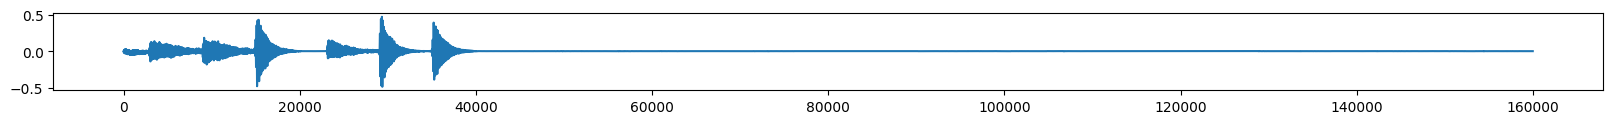

Finished epoch number 74 with a total of 10000 debug_seqs
 time: 2025-09-05 17:06:41.086765, epoch 75,  Loss: 0.0360
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


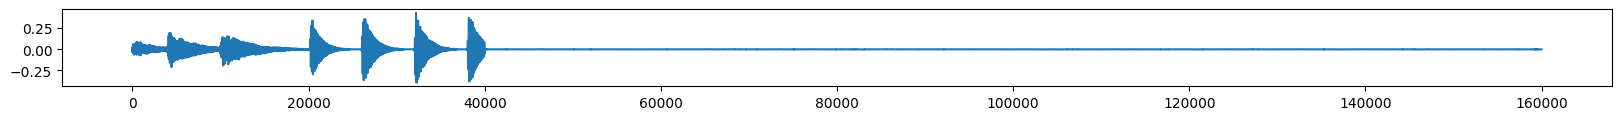

Finished epoch number 75 with a total of 10000 debug_seqs
 time: 2025-09-05 17:07:02.648641, epoch 76,  Loss: 0.0353
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


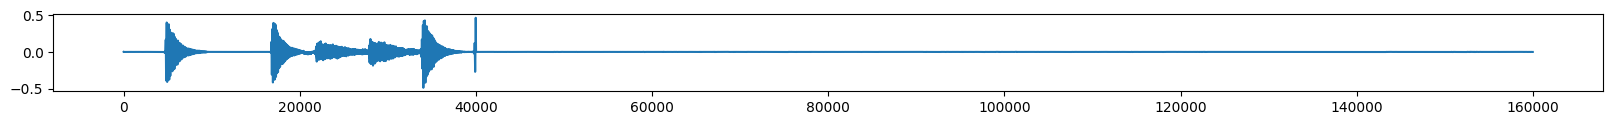

Finished epoch number 76 with a total of 10000 debug_seqs
 time: 2025-09-05 17:07:24.218554, epoch 77,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


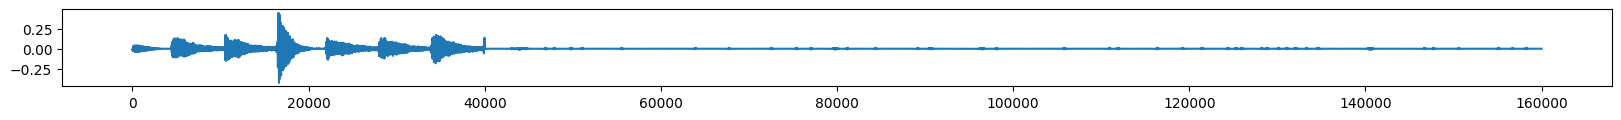

Finished epoch number 77 with a total of 10000 debug_seqs
 time: 2025-09-05 17:07:45.668483, epoch 78,  Loss: 0.0354
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


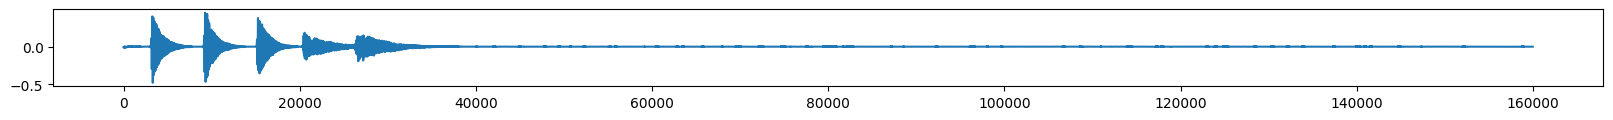

Finished epoch number 78 with a total of 10000 debug_seqs
 time: 2025-09-05 17:08:07.206623, epoch 79,  Loss: 0.0359
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.93. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


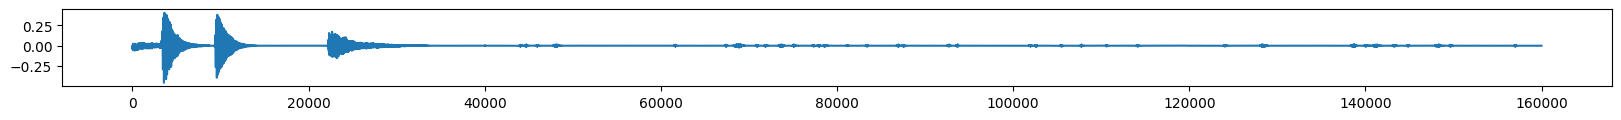

Finished epoch number 79 with a total of 10000 debug_seqs
 time: 2025-09-05 17:08:28.891847, epoch 80,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


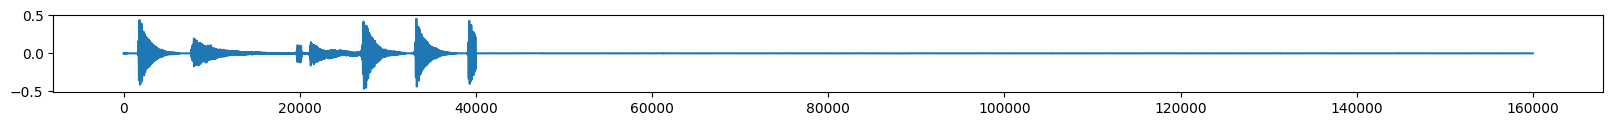

Saved checkpoint at epoch 80
Finished epoch number 80 with a total of 10000 debug_seqs
 time: 2025-09-05 17:08:50.452241, epoch 81,  Loss: 0.0354
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


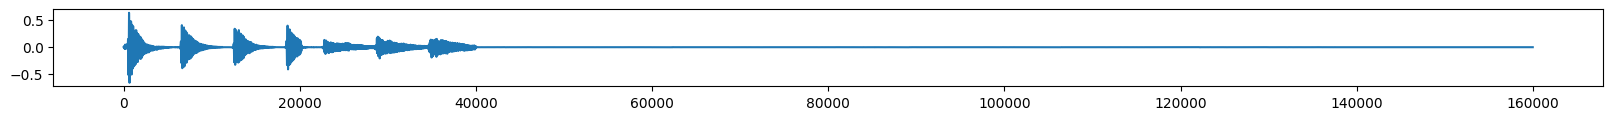

Finished epoch number 81 with a total of 10000 debug_seqs
 time: 2025-09-05 17:09:11.969766, epoch 82,  Loss: 0.0355
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


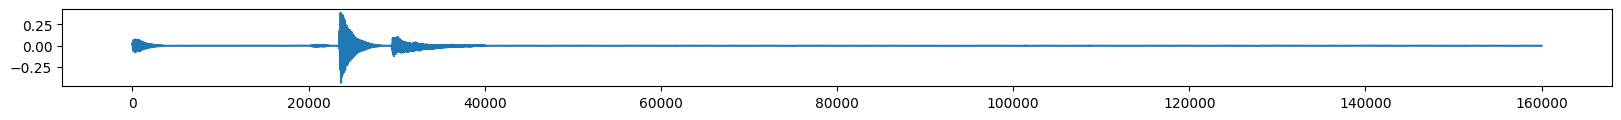

Finished epoch number 82 with a total of 10000 debug_seqs
 time: 2025-09-05 17:09:33.471851, epoch 83,  Loss: 0.0358
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


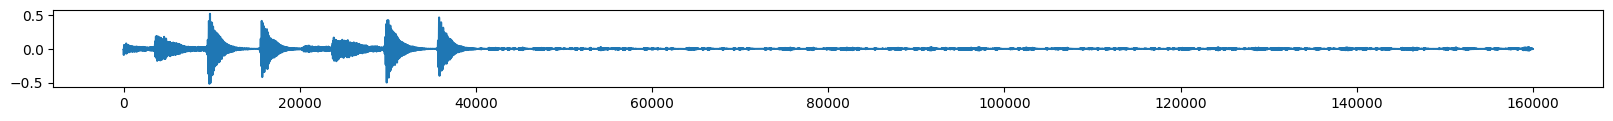

Finished epoch number 83 with a total of 10000 debug_seqs
 time: 2025-09-05 17:09:55.091820, epoch 84,  Loss: 0.0312
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


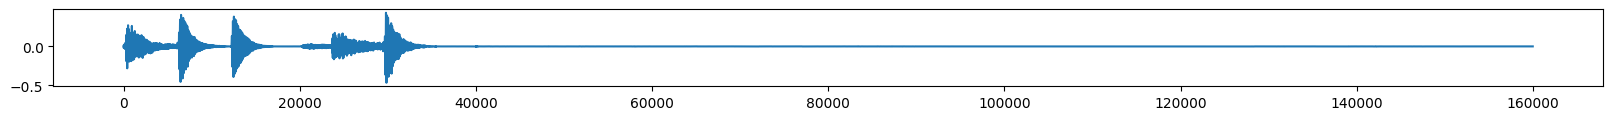

Finished epoch number 84 with a total of 10000 debug_seqs
 time: 2025-09-05 17:10:16.606279, epoch 85,  Loss: 0.0288
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


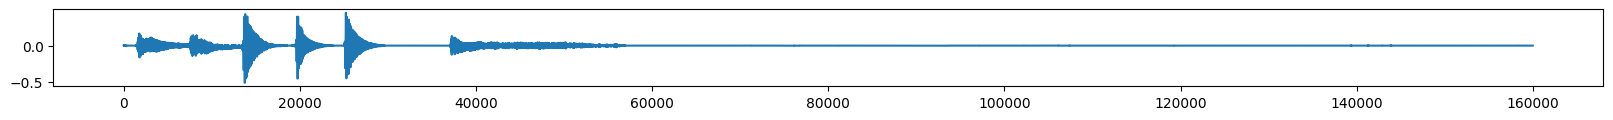

Finished epoch number 85 with a total of 10000 debug_seqs
 time: 2025-09-05 17:10:38.119086, epoch 86,  Loss: 0.0272
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


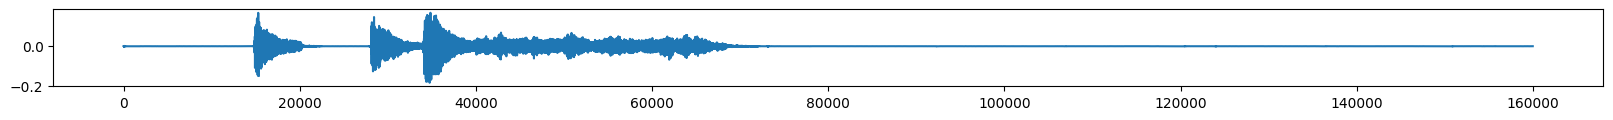

Finished epoch number 86 with a total of 10000 debug_seqs
 time: 2025-09-05 17:10:59.639758, epoch 87,  Loss: 0.0274
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


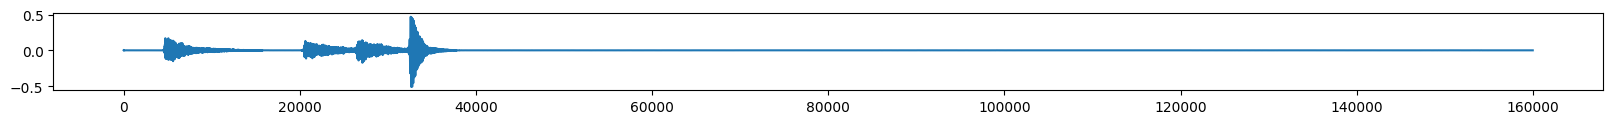

Finished epoch number 87 with a total of 10000 debug_seqs
 time: 2025-09-05 17:11:21.166262, epoch 88,  Loss: 0.0283
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


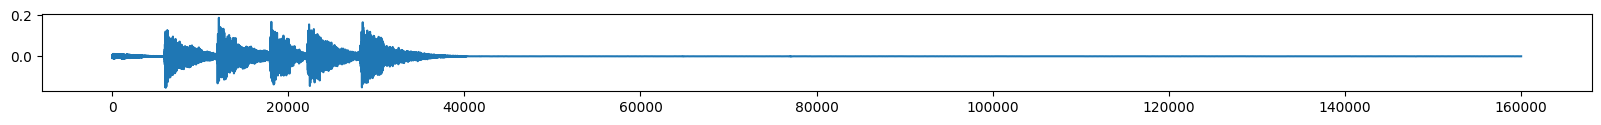

Finished epoch number 88 with a total of 10000 debug_seqs
 time: 2025-09-05 17:11:42.689572, epoch 89,  Loss: 0.0277
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


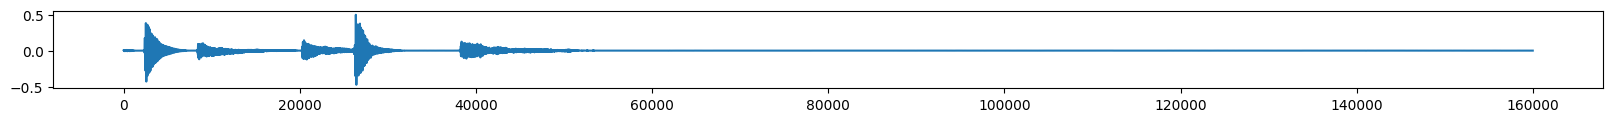

Finished epoch number 89 with a total of 10000 debug_seqs
 time: 2025-09-05 17:12:04.227861, epoch 90,  Loss: 0.0270
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


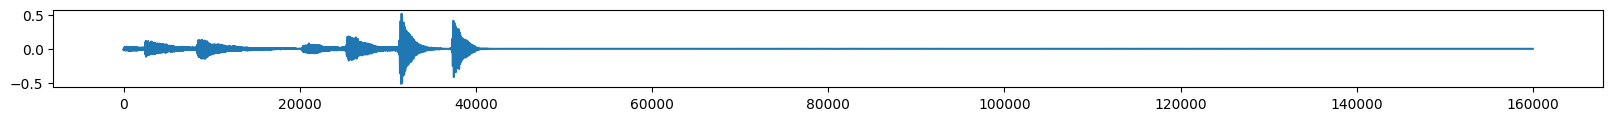

Saved checkpoint at epoch 90
Finished epoch number 90 with a total of 10000 debug_seqs
 time: 2025-09-05 17:12:25.785411, epoch 91,  Loss: 0.0262
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


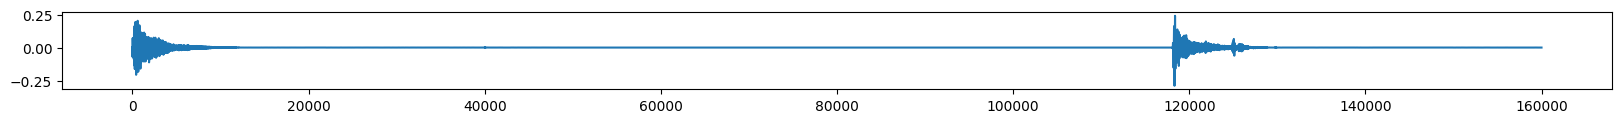

Finished epoch number 91 with a total of 10000 debug_seqs
 time: 2025-09-05 17:12:47.303437, epoch 92,  Loss: 0.0265
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


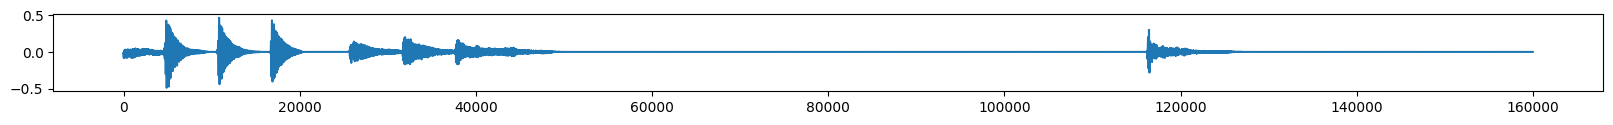

Finished epoch number 92 with a total of 10000 debug_seqs
 time: 2025-09-05 17:13:08.856733, epoch 93,  Loss: 0.0250
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


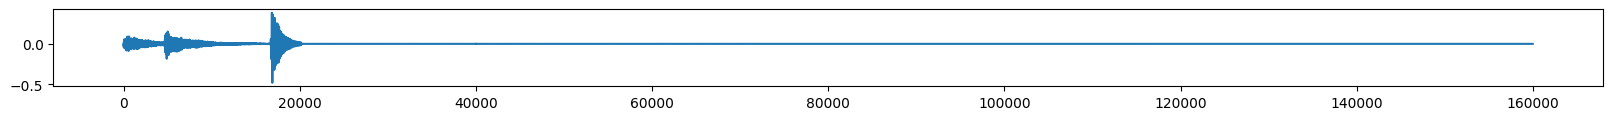

Finished epoch number 93 with a total of 10000 debug_seqs
 time: 2025-09-05 17:13:30.379129, epoch 94,  Loss: 0.0258
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


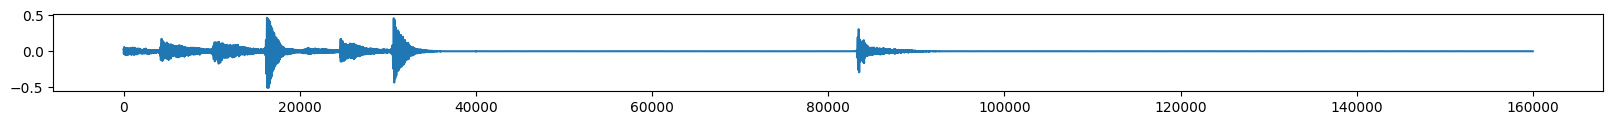

Finished epoch number 94 with a total of 10000 debug_seqs
 time: 2025-09-05 17:13:51.942647, epoch 95,  Loss: 0.0263
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


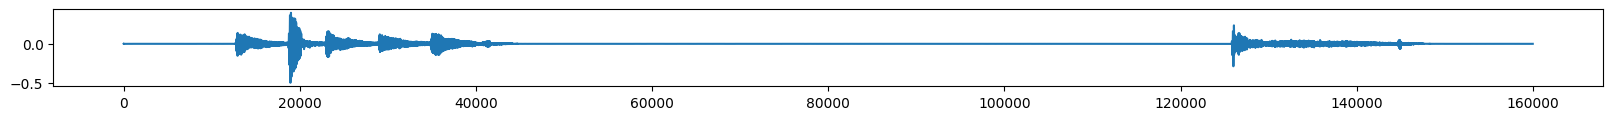

Finished epoch number 95 with a total of 10000 debug_seqs
 time: 2025-09-05 17:14:13.423492, epoch 96,  Loss: 0.0260
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


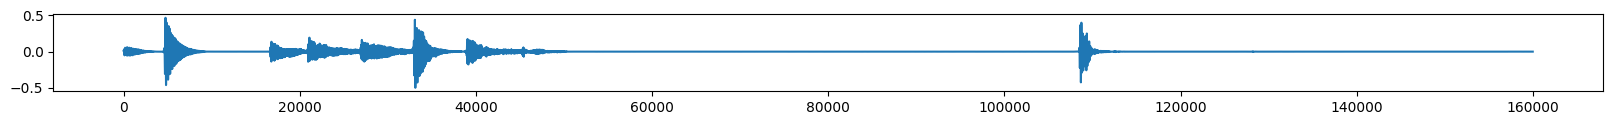

Finished epoch number 96 with a total of 10000 debug_seqs
 time: 2025-09-05 17:14:34.987448, epoch 97,  Loss: 0.0264
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


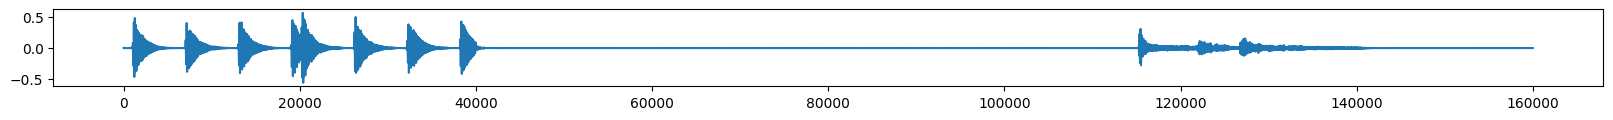

Finished epoch number 97 with a total of 10000 debug_seqs
 time: 2025-09-05 17:14:56.604107, epoch 98,  Loss: 0.0252
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


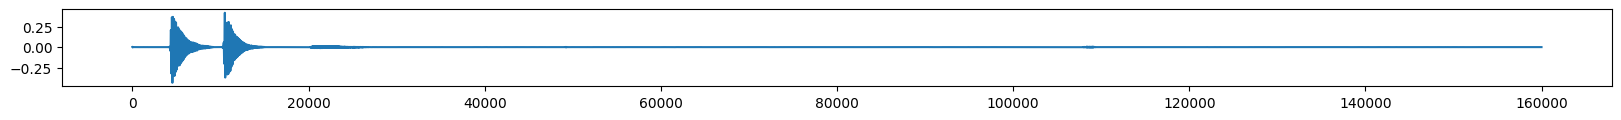

Finished epoch number 98 with a total of 10000 debug_seqs
 time: 2025-09-05 17:15:18.208615, epoch 99,  Loss: 0.0248
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


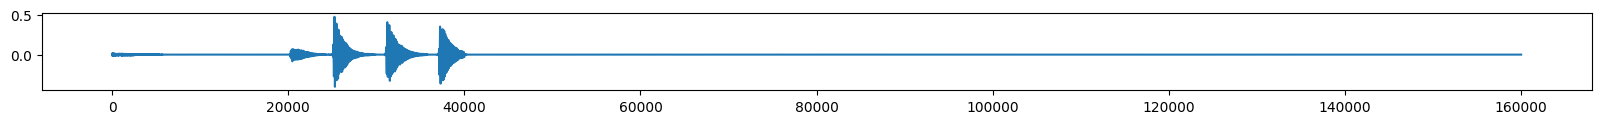

Finished epoch number 99 with a total of 10000 debug_seqs
 time: 2025-09-05 17:15:39.738275, epoch 100,  Loss: 0.0267
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


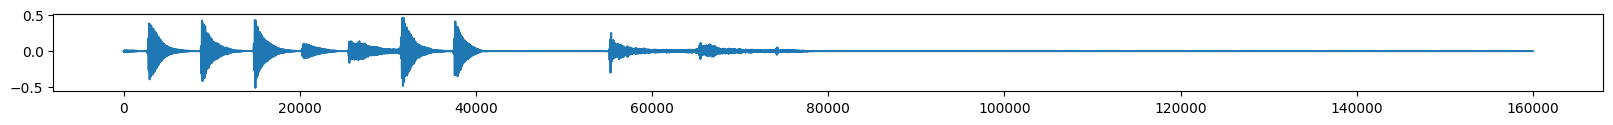

Saved checkpoint at epoch 100
Finished epoch number 100 with a total of 10000 debug_seqs
 time: 2025-09-05 17:16:01.351112, epoch 101,  Loss: 0.0255
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


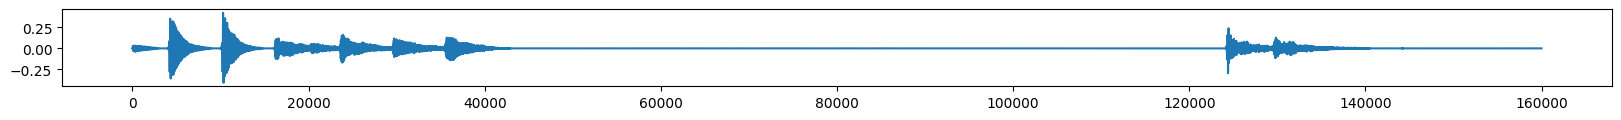

Finished epoch number 101 with a total of 10000 debug_seqs
 time: 2025-09-05 17:16:22.981106, epoch 102,  Loss: 0.0248
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


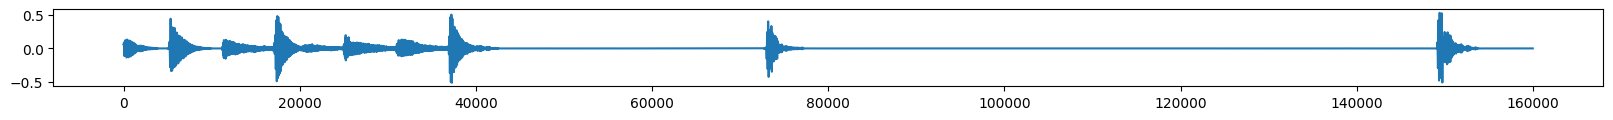

Finished epoch number 102 with a total of 10000 debug_seqs
 time: 2025-09-05 17:16:44.507162, epoch 103,  Loss: 0.0259
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


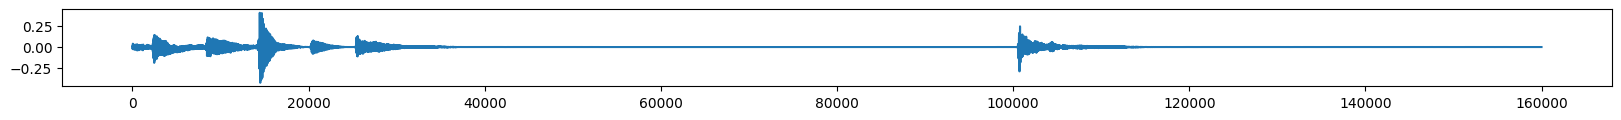

Finished epoch number 103 with a total of 10000 debug_seqs
 time: 2025-09-05 17:17:06.043547, epoch 104,  Loss: 0.0250
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


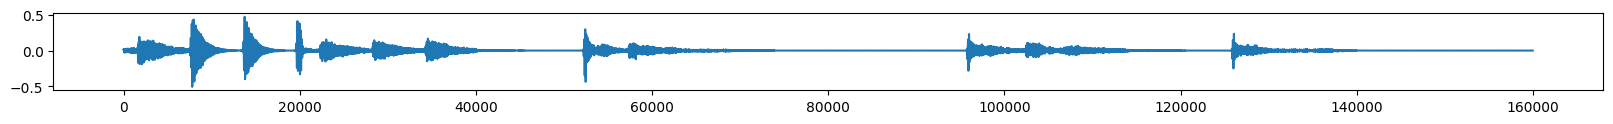

Finished epoch number 104 with a total of 10000 debug_seqs
 time: 2025-09-05 17:17:27.433685, epoch 105,  Loss: 0.0238
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


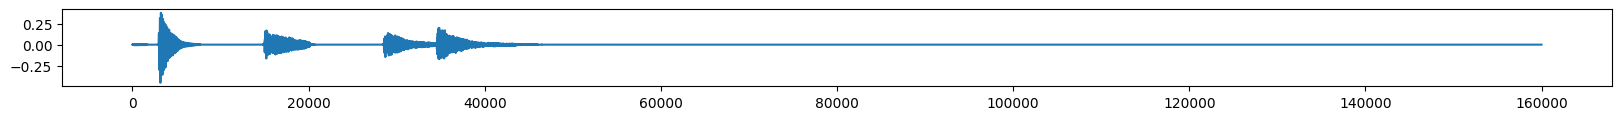

Finished epoch number 105 with a total of 10000 debug_seqs
 time: 2025-09-05 17:17:48.481693, epoch 106,  Loss: 0.0249
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


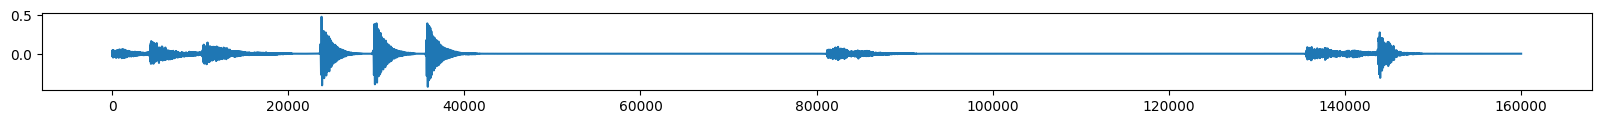

Finished epoch number 106 with a total of 10000 debug_seqs
 time: 2025-09-05 17:18:09.534647, epoch 107,  Loss: 0.0244
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


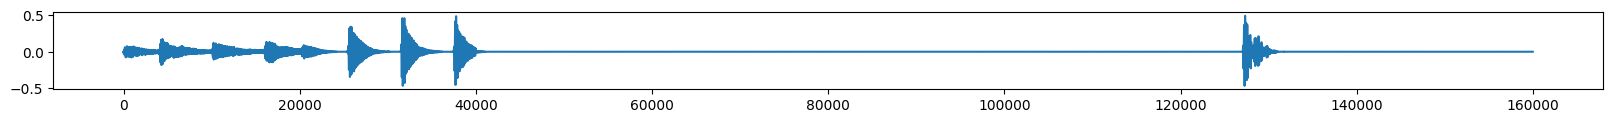

Finished epoch number 107 with a total of 10000 debug_seqs
 time: 2025-09-05 17:18:30.630718, epoch 108,  Loss: 0.0240
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


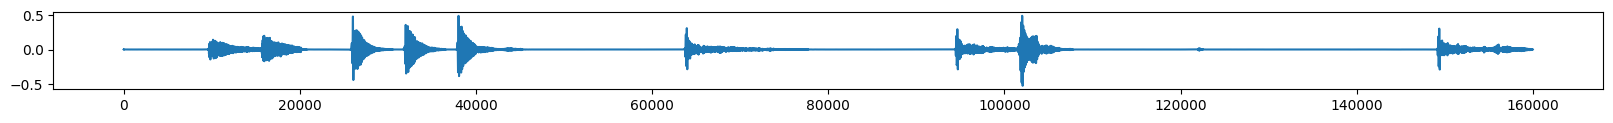

Finished epoch number 108 with a total of 10000 debug_seqs
 time: 2025-09-05 17:18:51.708930, epoch 109,  Loss: 0.0238
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


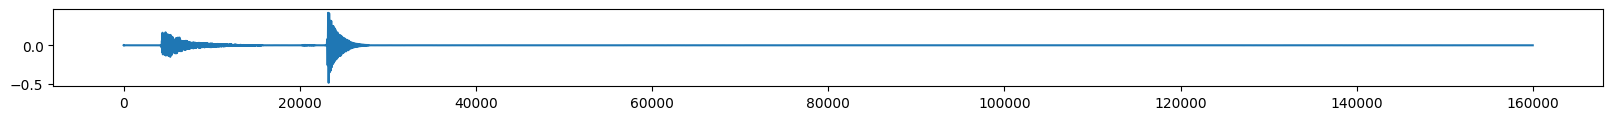

Finished epoch number 109 with a total of 10000 debug_seqs
 time: 2025-09-05 17:19:12.758458, epoch 110,  Loss: 0.0245
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.87. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


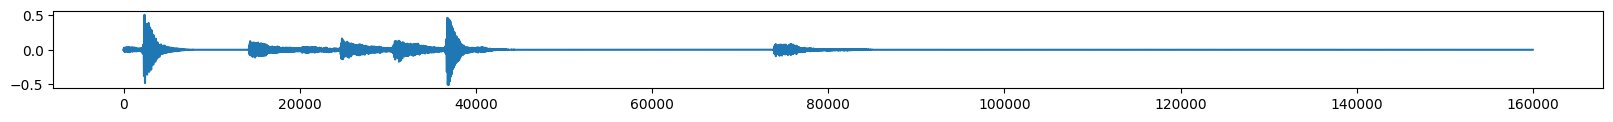

Saved checkpoint at epoch 110
Finished epoch number 110 with a total of 10000 debug_seqs
 time: 2025-09-05 17:19:33.841027, epoch 111,  Loss: 0.0249
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


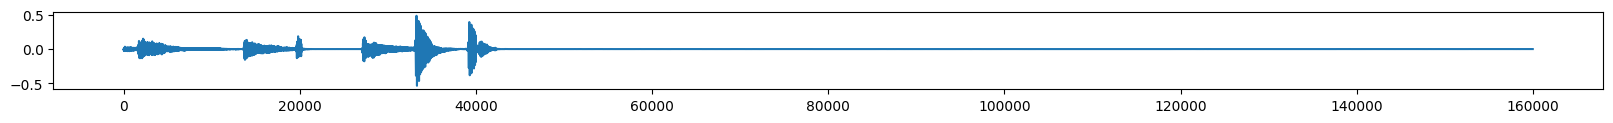

Finished epoch number 111 with a total of 10000 debug_seqs
 time: 2025-09-05 17:19:54.932789, epoch 112,  Loss: 0.0237
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


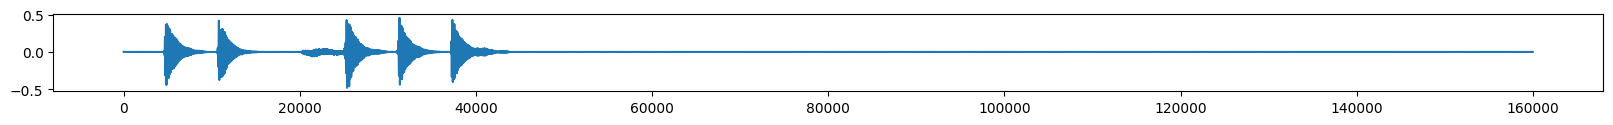

Finished epoch number 112 with a total of 10000 debug_seqs
 time: 2025-09-05 17:20:16.010704, epoch 113,  Loss: 0.0227
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


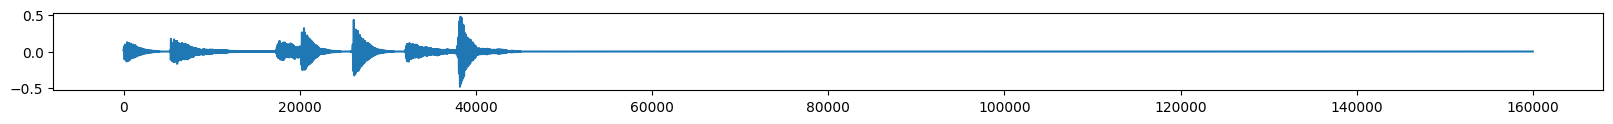

Finished epoch number 113 with a total of 10000 debug_seqs
 time: 2025-09-05 17:20:37.142889, epoch 114,  Loss: 0.0230
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


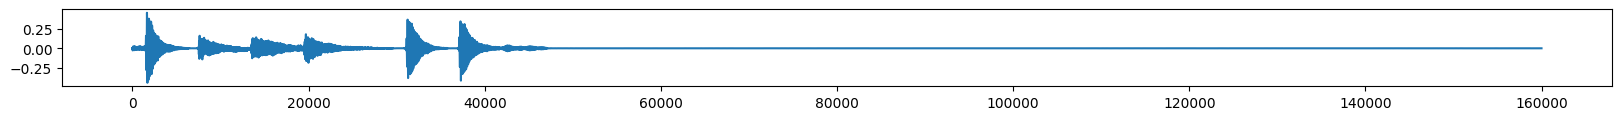

Finished epoch number 114 with a total of 10000 debug_seqs
 time: 2025-09-05 17:20:58.265603, epoch 115,  Loss: 0.0226
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


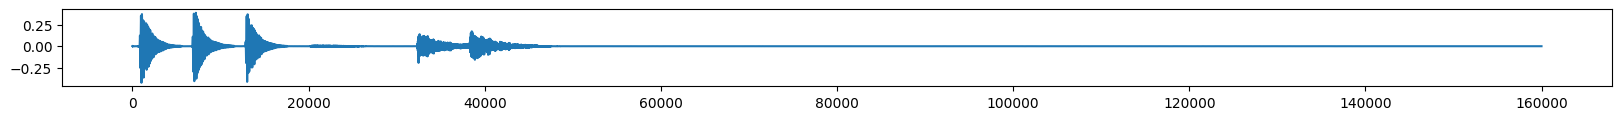

Finished epoch number 115 with a total of 10000 debug_seqs
 time: 2025-09-05 17:21:19.350874, epoch 116,  Loss: 0.0232
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


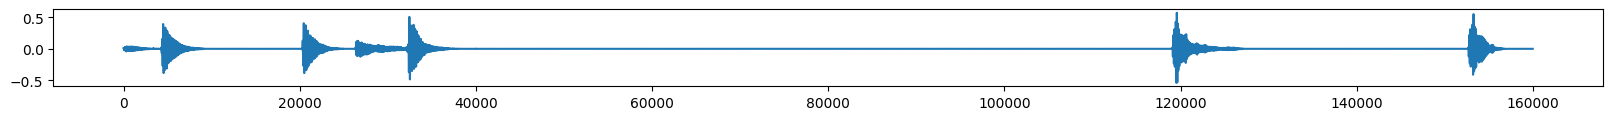

Finished epoch number 116 with a total of 10000 debug_seqs
 time: 2025-09-05 17:21:40.466985, epoch 117,  Loss: 0.0226
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


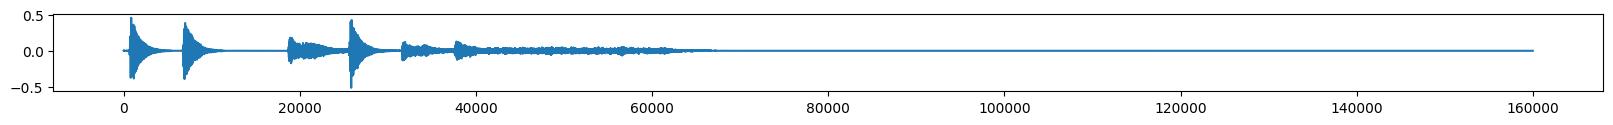

Finished epoch number 117 with a total of 10000 debug_seqs
 time: 2025-09-05 17:22:01.582185, epoch 118,  Loss: 0.0217
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


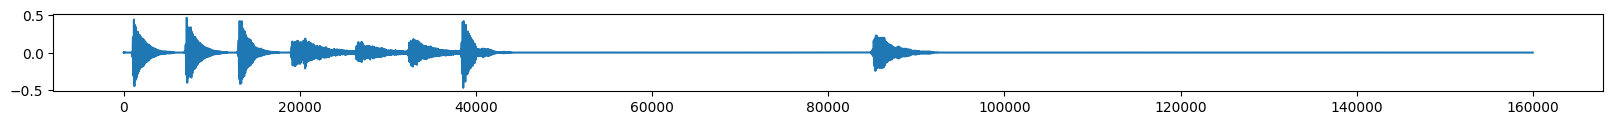

Finished epoch number 118 with a total of 10000 debug_seqs
 time: 2025-09-05 17:22:22.655658, epoch 119,  Loss: 0.0224
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


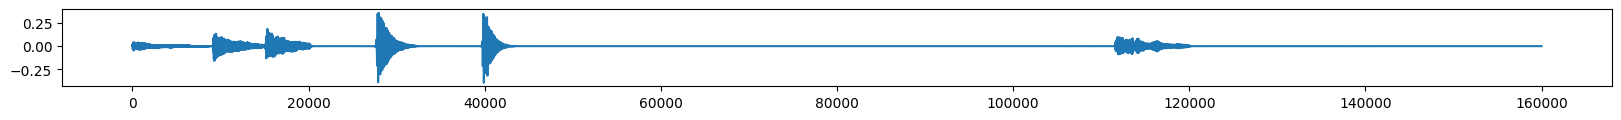

Finished epoch number 119 with a total of 10000 debug_seqs
 time: 2025-09-05 17:22:43.829102, epoch 120,  Loss: 0.0219
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


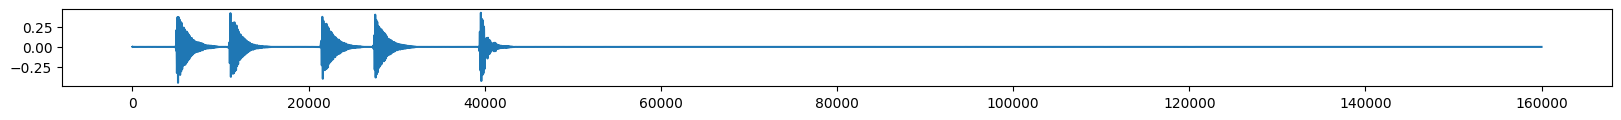

Saved checkpoint at epoch 120
Finished epoch number 120 with a total of 10000 debug_seqs
 time: 2025-09-05 17:23:04.871996, epoch 121,  Loss: 0.0222
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


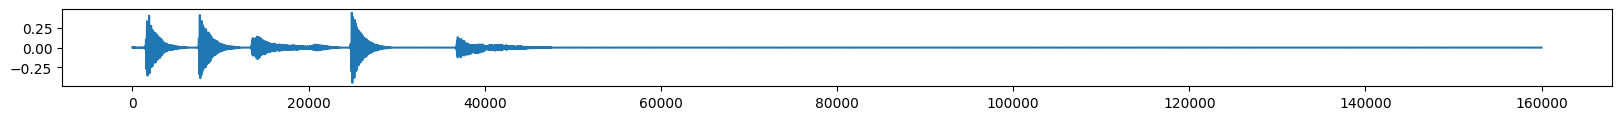

Finished epoch number 121 with a total of 10000 debug_seqs
 time: 2025-09-05 17:23:25.976682, epoch 122,  Loss: 0.0216
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


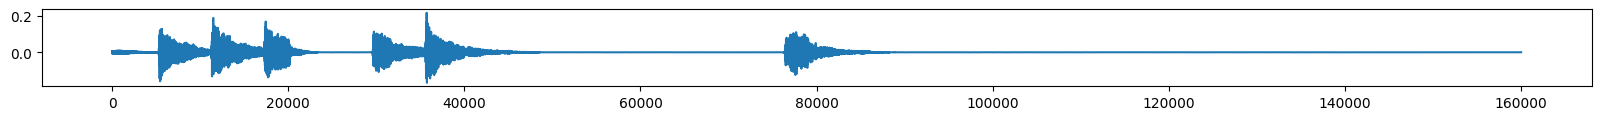

Finished epoch number 122 with a total of 10000 debug_seqs
 time: 2025-09-05 17:23:47.016373, epoch 123,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


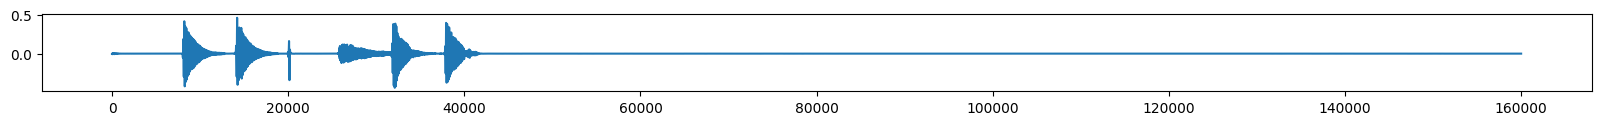

Finished epoch number 123 with a total of 10000 debug_seqs
 time: 2025-09-05 17:24:08.112812, epoch 124,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.88. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


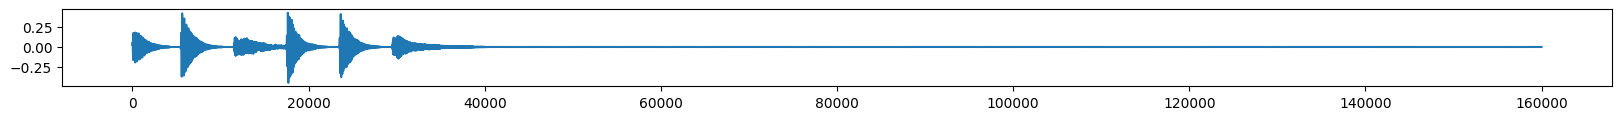

Finished epoch number 124 with a total of 10000 debug_seqs
 time: 2025-09-05 17:24:29.739139, epoch 125,  Loss: 0.0218
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


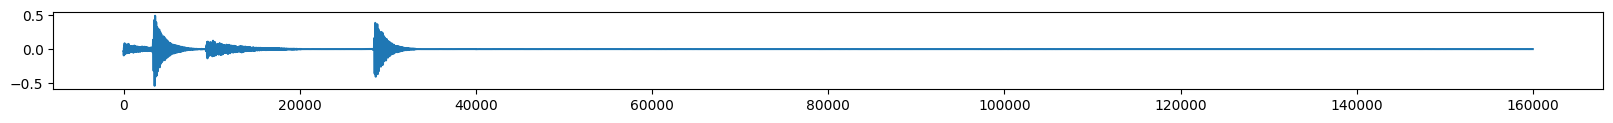

Finished epoch number 125 with a total of 10000 debug_seqs
 time: 2025-09-05 17:24:51.357651, epoch 126,  Loss: 0.0215
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


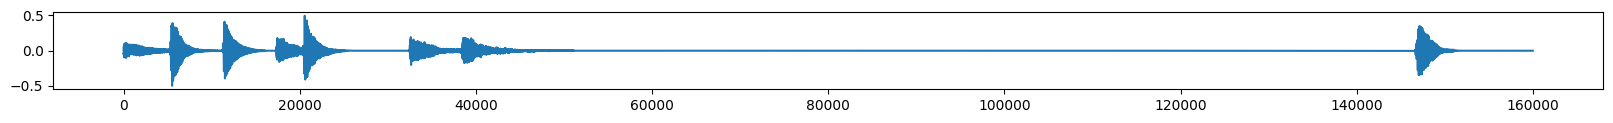

Finished epoch number 126 with a total of 10000 debug_seqs
 time: 2025-09-05 17:25:12.874904, epoch 127,  Loss: 0.0216
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


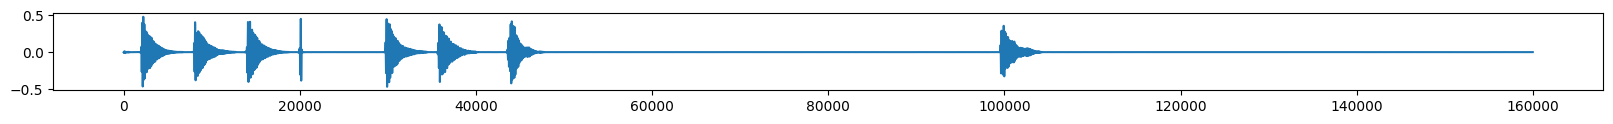

Finished epoch number 127 with a total of 10000 debug_seqs
 time: 2025-09-05 17:25:34.338294, epoch 128,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


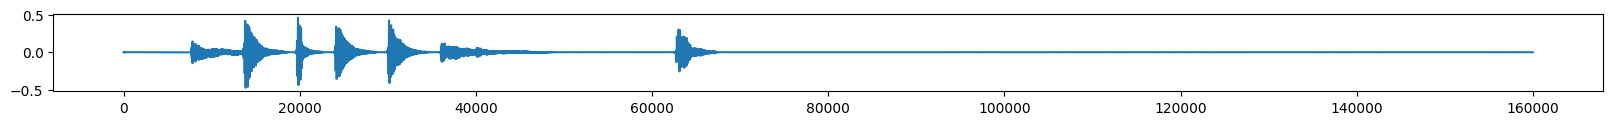

Finished epoch number 128 with a total of 10000 debug_seqs
 time: 2025-09-05 17:25:55.979776, epoch 129,  Loss: 0.0219
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


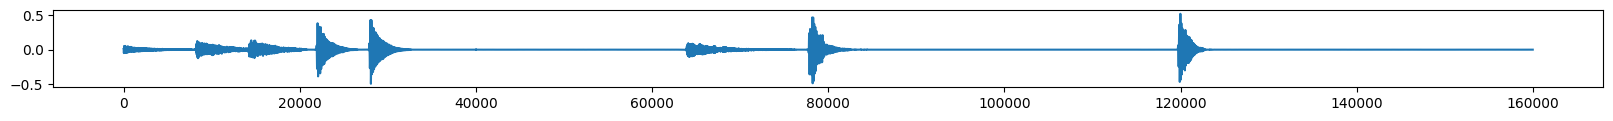

Finished epoch number 129 with a total of 10000 debug_seqs
 time: 2025-09-05 17:26:17.470872, epoch 130,  Loss: 0.0215
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


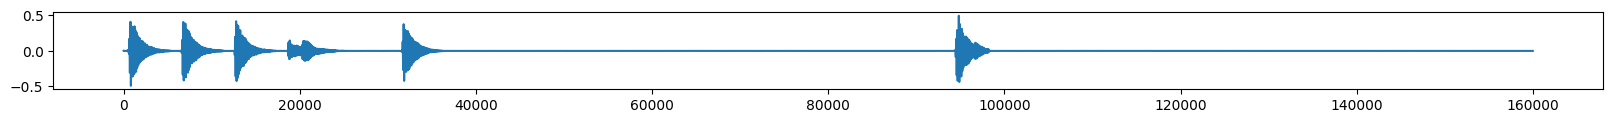

Saved checkpoint at epoch 130
Finished epoch number 130 with a total of 10000 debug_seqs
 time: 2025-09-05 17:26:38.958006, epoch 131,  Loss: 0.0234
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


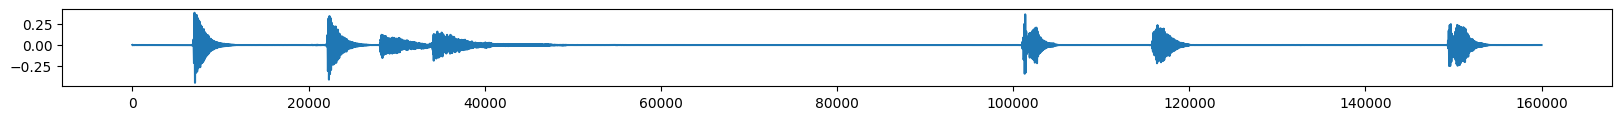

Finished epoch number 131 with a total of 10000 debug_seqs
 time: 2025-09-05 17:27:00.454396, epoch 132,  Loss: 0.0214
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


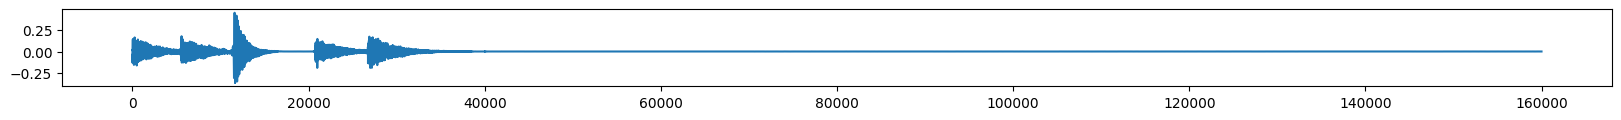

Finished epoch number 132 with a total of 10000 debug_seqs
 time: 2025-09-05 17:27:21.946229, epoch 133,  Loss: 0.0213
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.93. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


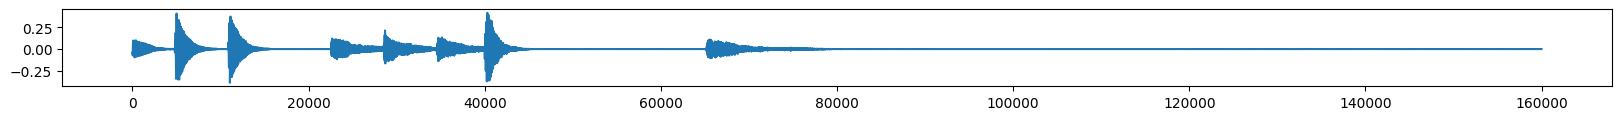

Finished epoch number 133 with a total of 10000 debug_seqs
 time: 2025-09-05 17:27:43.547723, epoch 134,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


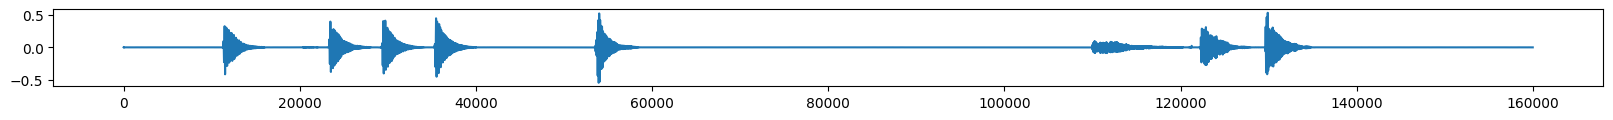

Finished epoch number 134 with a total of 10000 debug_seqs
 time: 2025-09-05 17:28:05.041981, epoch 135,  Loss: 0.0204
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


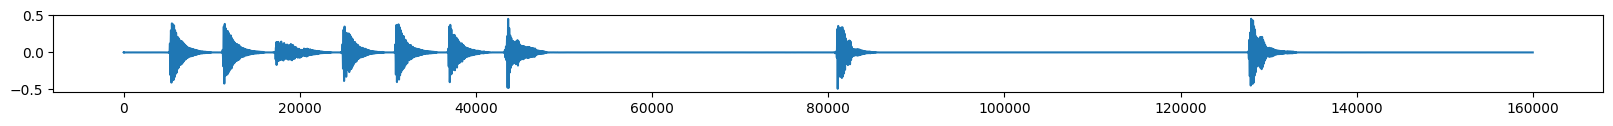

Finished epoch number 135 with a total of 10000 debug_seqs
 time: 2025-09-05 17:28:26.531760, epoch 136,  Loss: 0.0211
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


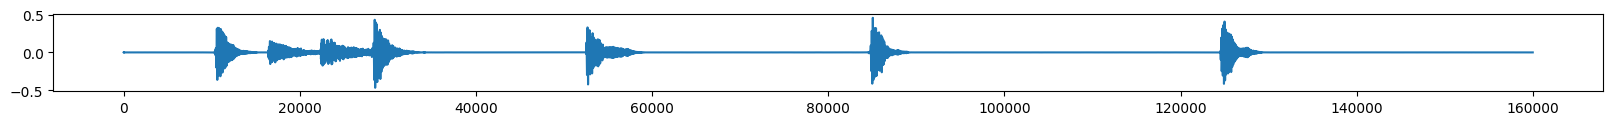

Finished epoch number 136 with a total of 10000 debug_seqs
 time: 2025-09-05 17:28:48.042798, epoch 137,  Loss: 0.0202
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


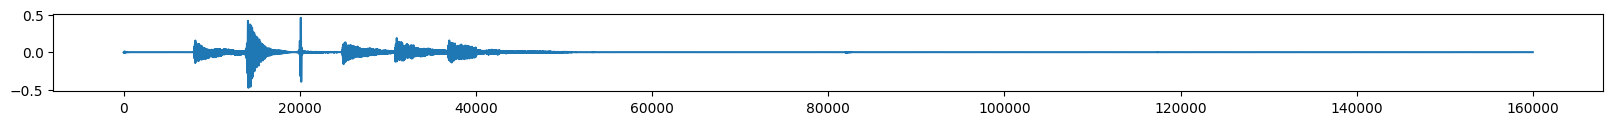

Finished epoch number 137 with a total of 10000 debug_seqs
 time: 2025-09-05 17:29:09.515071, epoch 138,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


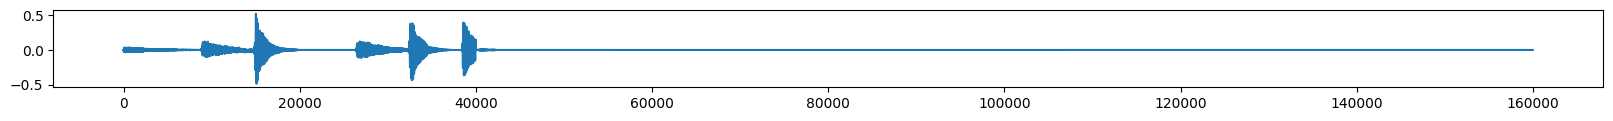

Finished epoch number 138 with a total of 10000 debug_seqs
 time: 2025-09-05 17:29:30.980197, epoch 139,  Loss: 0.0209
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


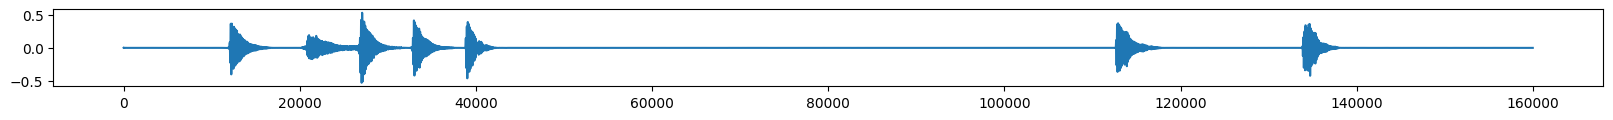

Finished epoch number 139 with a total of 10000 debug_seqs
 time: 2025-09-05 17:29:52.519584, epoch 140,  Loss: 0.0211
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


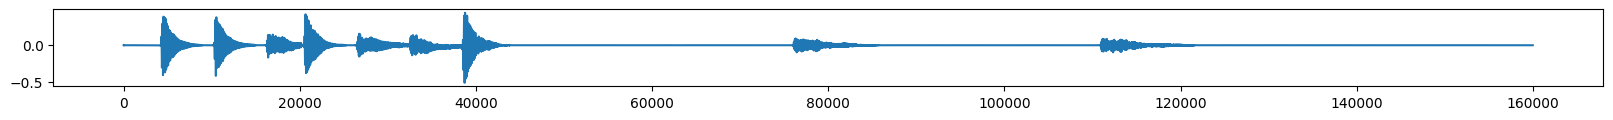

Saved checkpoint at epoch 140
Finished epoch number 140 with a total of 10000 debug_seqs
 time: 2025-09-05 17:30:14.028960, epoch 141,  Loss: 0.0209
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


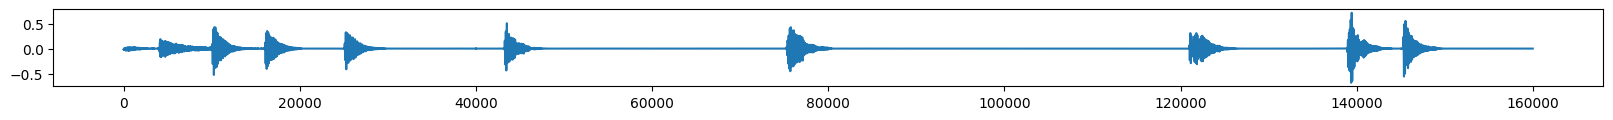

Finished epoch number 141 with a total of 10000 debug_seqs
 time: 2025-09-05 17:30:35.579634, epoch 142,  Loss: 0.0205
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


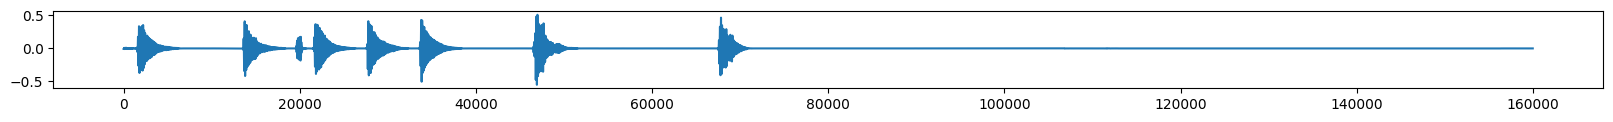

Finished epoch number 142 with a total of 10000 debug_seqs
 time: 2025-09-05 17:30:57.112577, epoch 143,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


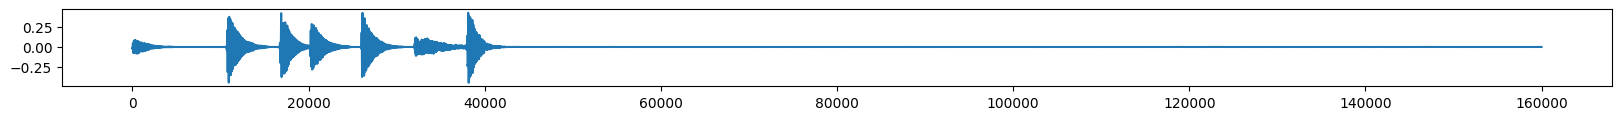

Finished epoch number 143 with a total of 10000 debug_seqs
 time: 2025-09-05 17:31:18.606608, epoch 144,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


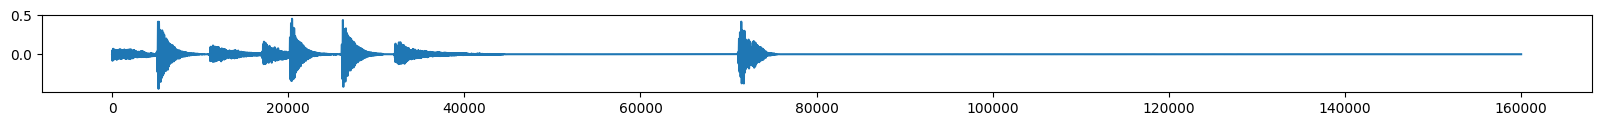

Finished epoch number 144 with a total of 10000 debug_seqs
 time: 2025-09-05 17:31:40.162612, epoch 145,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


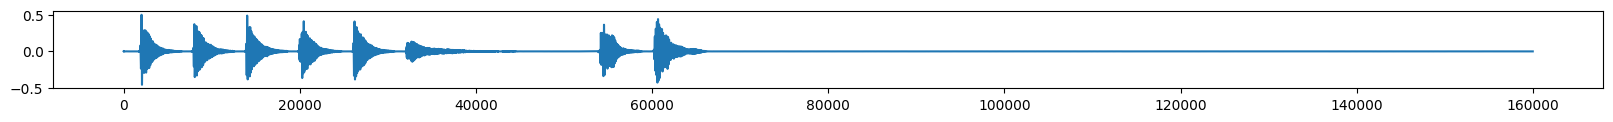

Finished epoch number 145 with a total of 10000 debug_seqs
 time: 2025-09-05 17:32:01.680698, epoch 146,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


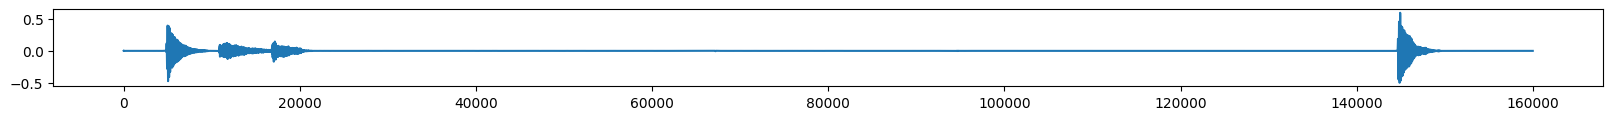

Finished epoch number 146 with a total of 10000 debug_seqs
 time: 2025-09-05 17:32:23.195051, epoch 147,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


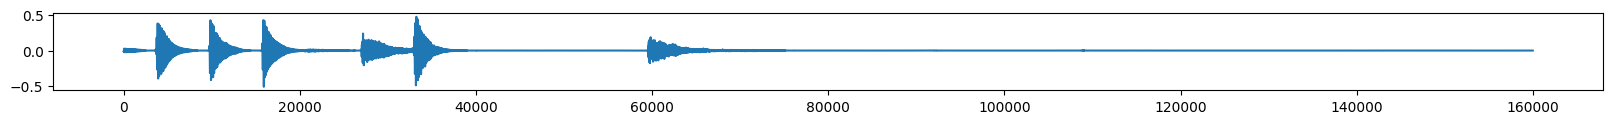

Finished epoch number 147 with a total of 10000 debug_seqs
 time: 2025-09-05 17:32:44.737628, epoch 148,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


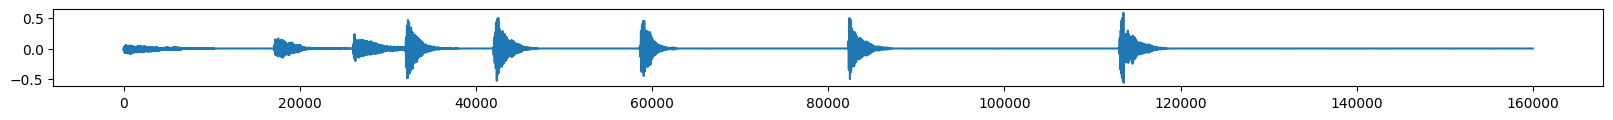

Finished epoch number 148 with a total of 10000 debug_seqs
 time: 2025-09-05 17:33:06.292815, epoch 149,  Loss: 0.0211
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


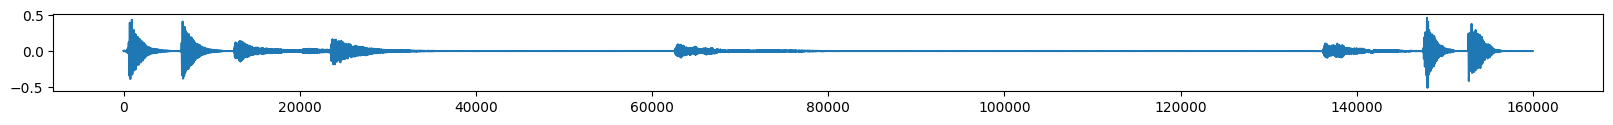

Finished epoch number 149 with a total of 10000 debug_seqs
 time: 2025-09-05 17:33:27.869618, epoch 150,  Loss: 0.0205
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.93. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


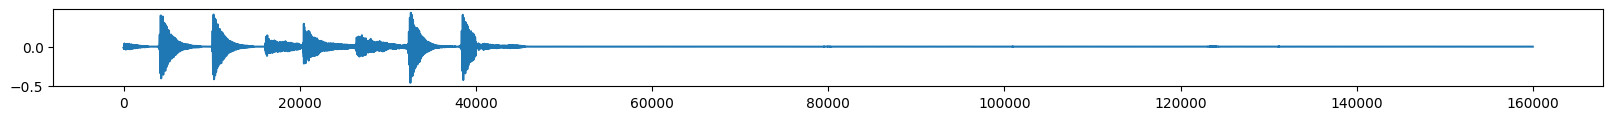

Saved checkpoint at epoch 150
Finished epoch number 150 with a total of 10000 debug_seqs
 time: 2025-09-05 17:33:49.501731, epoch 151,  Loss: 0.0207
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


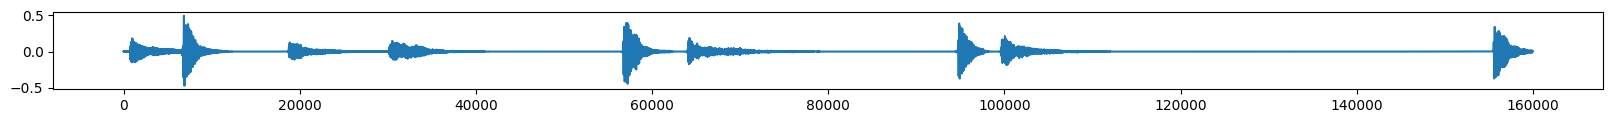

Finished epoch number 151 with a total of 10000 debug_seqs
 time: 2025-09-05 17:34:11.034147, epoch 152,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


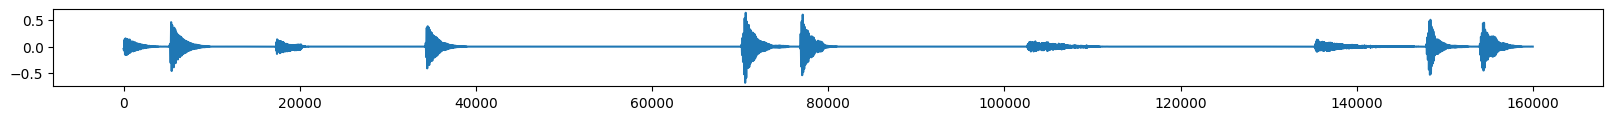

Finished epoch number 152 with a total of 10000 debug_seqs
 time: 2025-09-05 17:34:32.628708, epoch 153,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


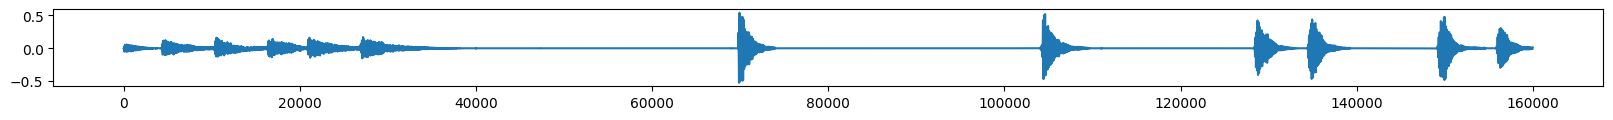

Finished epoch number 153 with a total of 10000 debug_seqs
 time: 2025-09-05 17:34:54.157787, epoch 154,  Loss: 0.0208
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


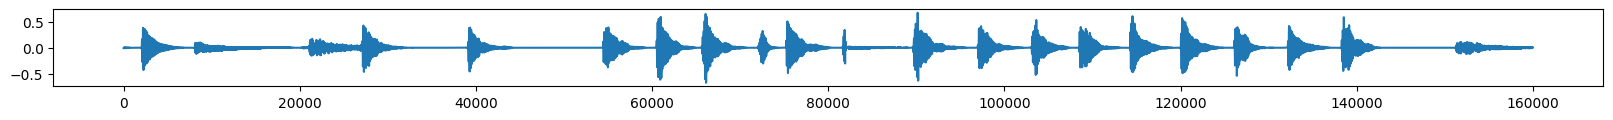

Finished epoch number 154 with a total of 10000 debug_seqs
 time: 2025-09-05 17:35:15.669715, epoch 155,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


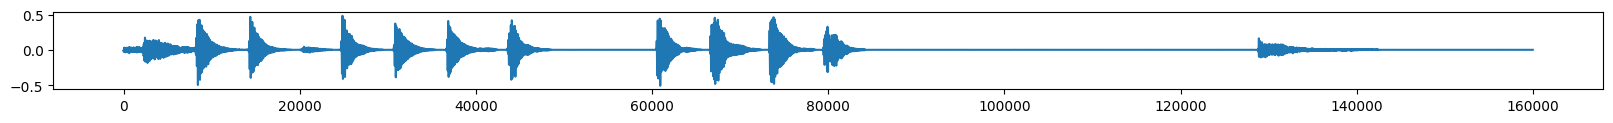

Finished epoch number 155 with a total of 10000 debug_seqs
 time: 2025-09-05 17:35:37.168471, epoch 156,  Loss: 0.0202
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


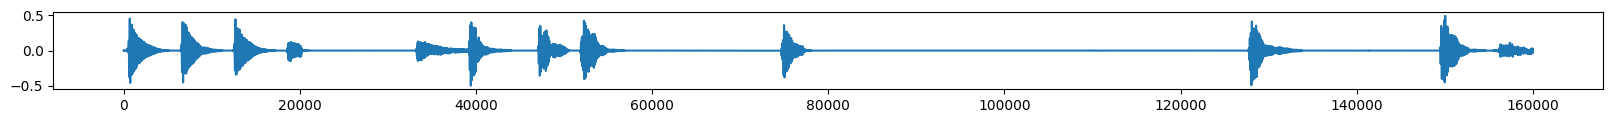

Finished epoch number 156 with a total of 10000 debug_seqs
 time: 2025-09-05 17:35:58.705823, epoch 157,  Loss: 0.0197
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


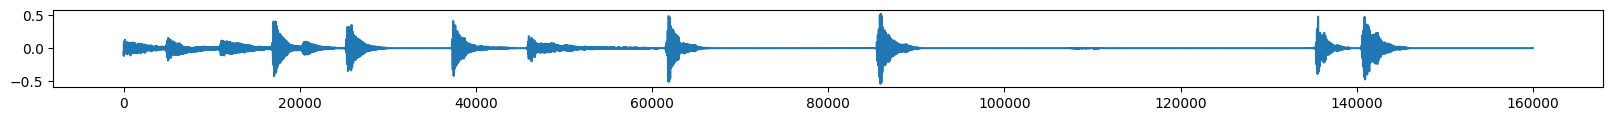

Finished epoch number 157 with a total of 10000 debug_seqs
 time: 2025-09-05 17:36:20.226695, epoch 158,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


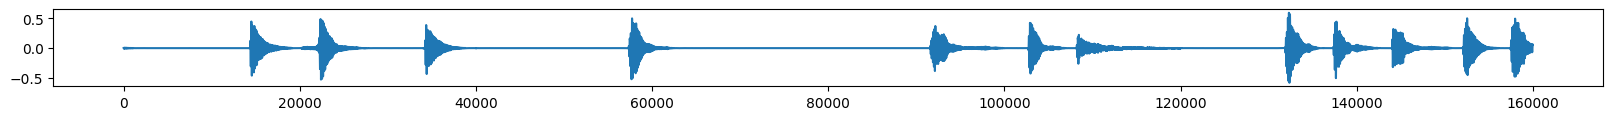

Finished epoch number 158 with a total of 10000 debug_seqs
 time: 2025-09-05 17:36:41.712435, epoch 159,  Loss: 0.0199
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


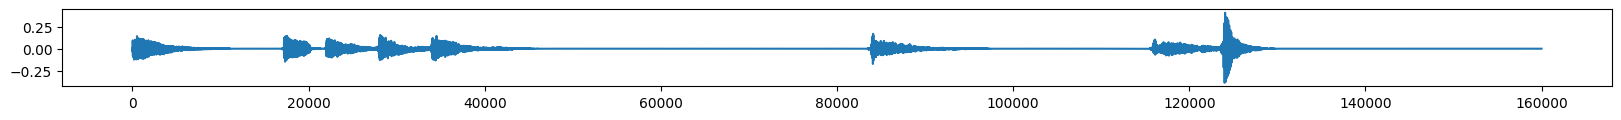

Finished epoch number 159 with a total of 10000 debug_seqs
 time: 2025-09-05 17:37:03.216931, epoch 160,  Loss: 0.0199
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


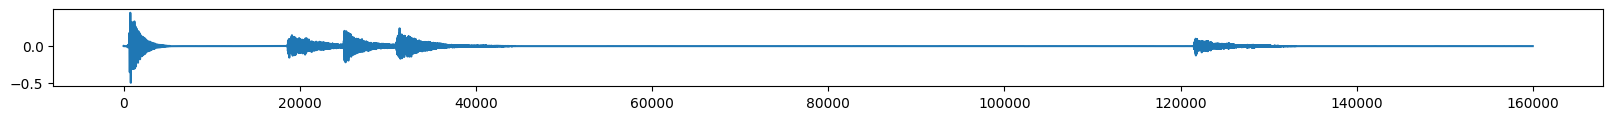

Saved checkpoint at epoch 160
Finished epoch number 160 with a total of 10000 debug_seqs
 time: 2025-09-05 17:37:24.742399, epoch 161,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


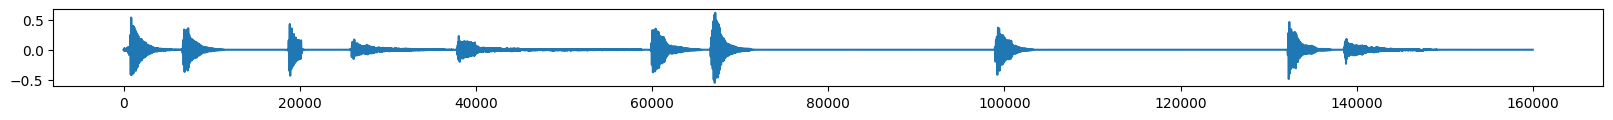

Finished epoch number 161 with a total of 10000 debug_seqs
 time: 2025-09-05 17:37:46.308143, epoch 162,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


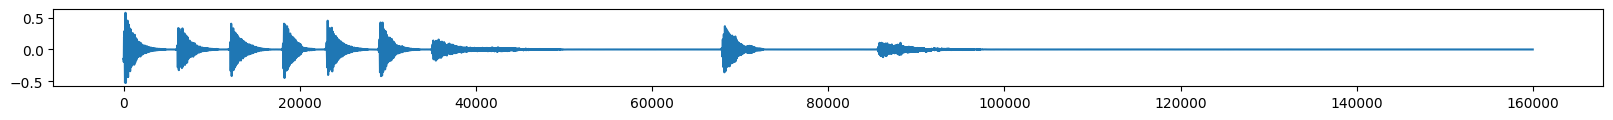

Finished epoch number 162 with a total of 10000 debug_seqs
 time: 2025-09-05 17:38:07.779074, epoch 163,  Loss: 0.0198
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


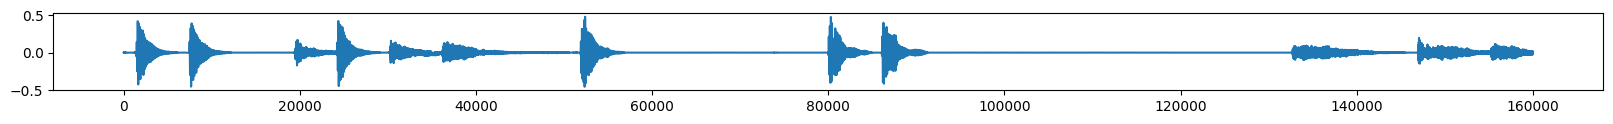

Finished epoch number 163 with a total of 10000 debug_seqs
 time: 2025-09-05 17:38:29.346542, epoch 164,  Loss: 0.0199
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


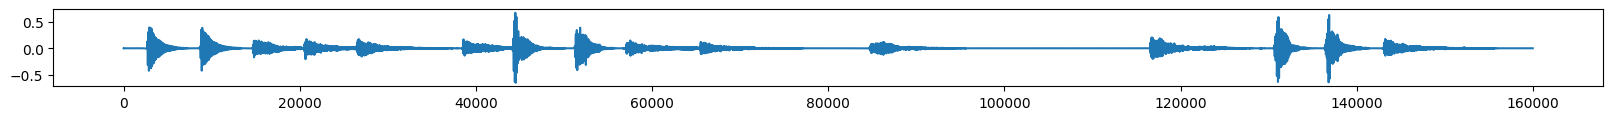

Finished epoch number 164 with a total of 10000 debug_seqs
 time: 2025-09-05 17:38:50.861276, epoch 165,  Loss: 0.0210
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


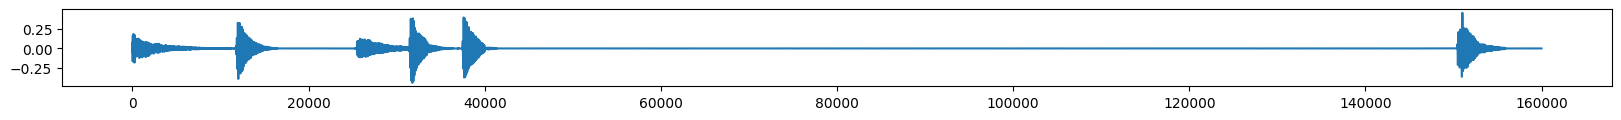

Finished epoch number 165 with a total of 10000 debug_seqs
 time: 2025-09-05 17:39:12.374220, epoch 166,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


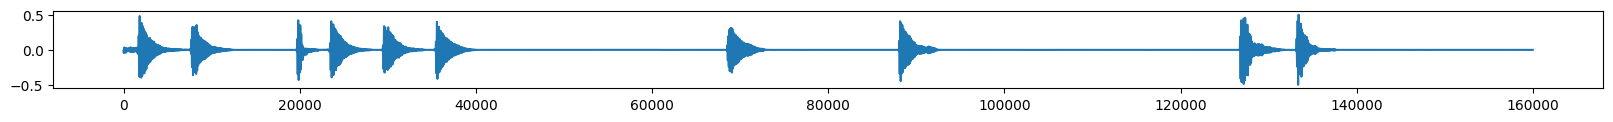

Finished epoch number 166 with a total of 10000 debug_seqs
 time: 2025-09-05 17:39:33.887856, epoch 167,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


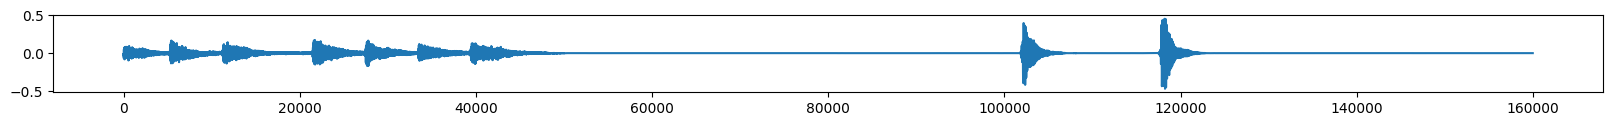

Finished epoch number 167 with a total of 10000 debug_seqs
 time: 2025-09-05 17:39:55.504900, epoch 168,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


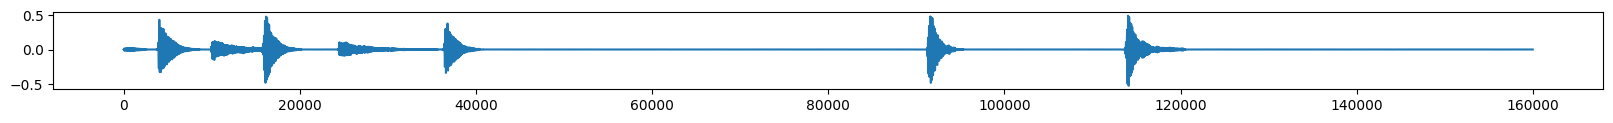

Finished epoch number 168 with a total of 10000 debug_seqs
 time: 2025-09-05 17:40:17.083489, epoch 169,  Loss: 0.0197
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


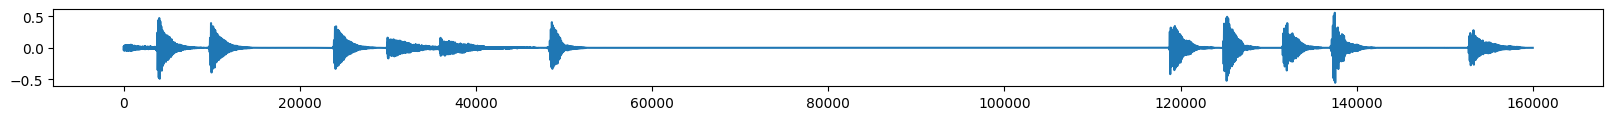

Finished epoch number 169 with a total of 10000 debug_seqs
 time: 2025-09-05 17:40:38.593716, epoch 170,  Loss: 0.0197
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


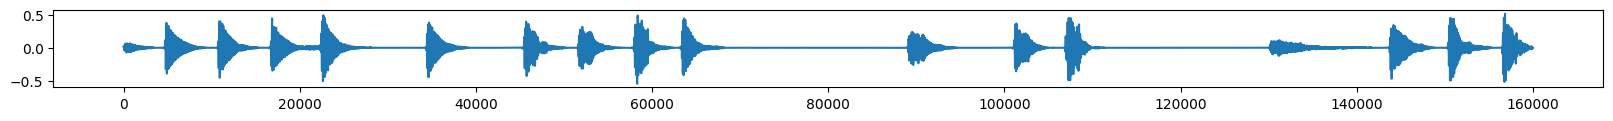

Saved checkpoint at epoch 170
Finished epoch number 170 with a total of 10000 debug_seqs
 time: 2025-09-05 17:41:00.095032, epoch 171,  Loss: 0.0198
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


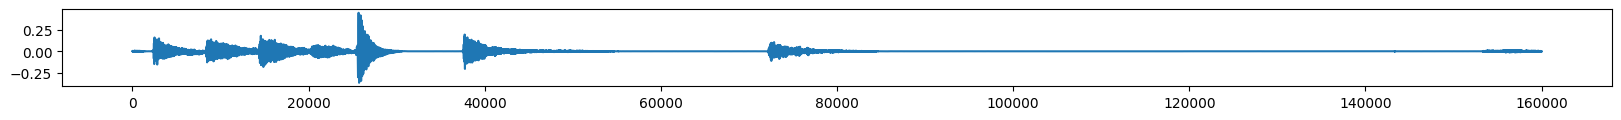

Finished epoch number 171 with a total of 10000 debug_seqs
 time: 2025-09-05 17:41:21.592916, epoch 172,  Loss: 0.0192
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


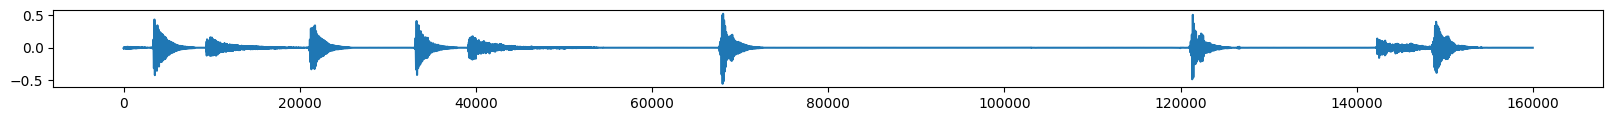

Finished epoch number 172 with a total of 10000 debug_seqs
 time: 2025-09-05 17:41:43.119144, epoch 173,  Loss: 0.0208
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


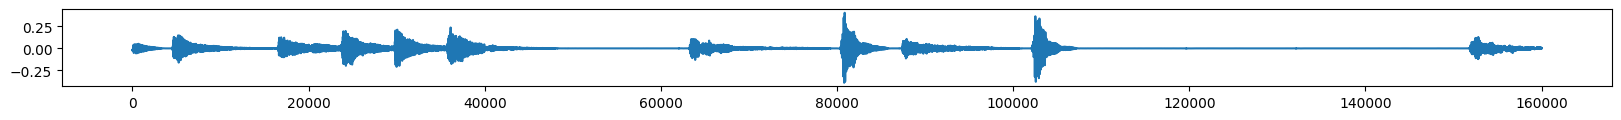

Finished epoch number 173 with a total of 10000 debug_seqs
 time: 2025-09-05 17:42:04.681375, epoch 174,  Loss: 0.0198
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


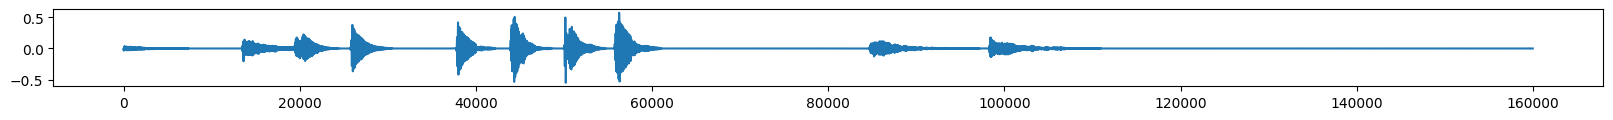

Finished epoch number 174 with a total of 10000 debug_seqs
 time: 2025-09-05 17:42:26.196994, epoch 175,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


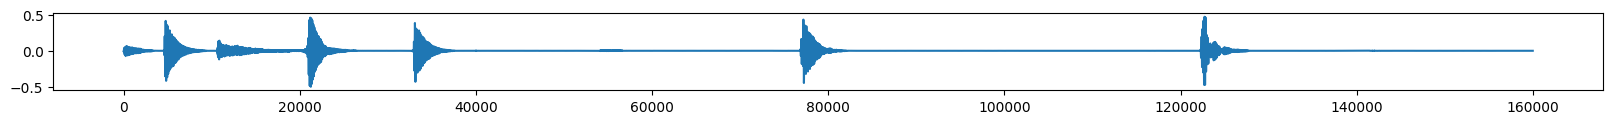

Finished epoch number 175 with a total of 10000 debug_seqs
 time: 2025-09-05 17:42:47.774029, epoch 176,  Loss: 0.0210
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


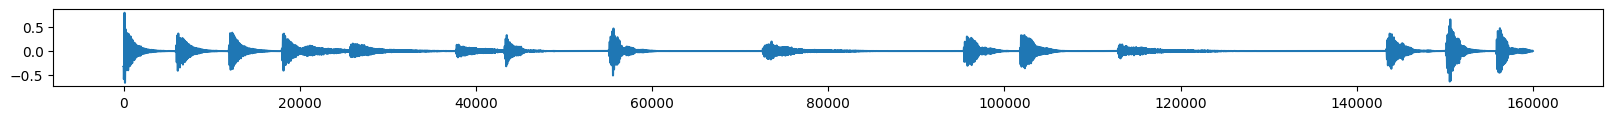

Finished epoch number 176 with a total of 10000 debug_seqs
 time: 2025-09-05 17:43:09.312339, epoch 177,  Loss: 0.0192
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


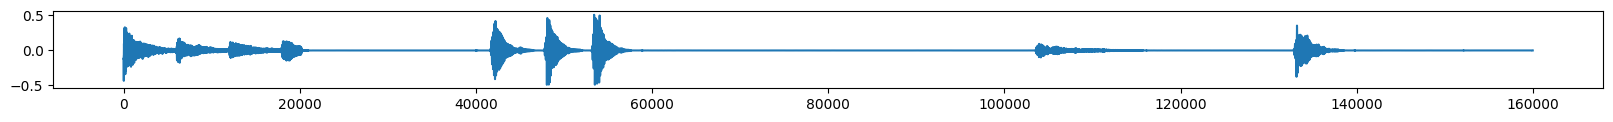

Finished epoch number 177 with a total of 10000 debug_seqs
 time: 2025-09-05 17:43:30.842963, epoch 178,  Loss: 0.0197
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


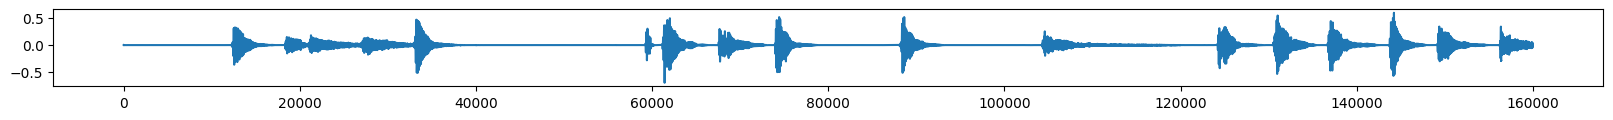

Finished epoch number 178 with a total of 10000 debug_seqs
 time: 2025-09-05 17:43:52.345681, epoch 179,  Loss: 0.0198
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


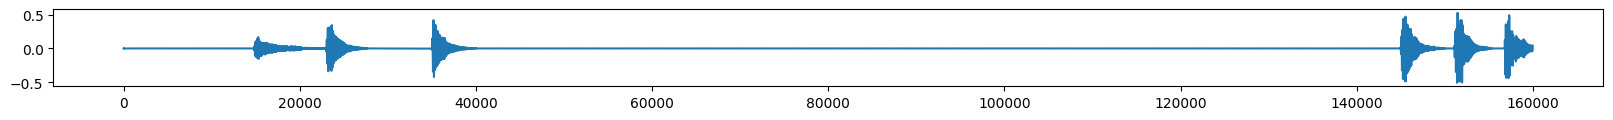

Finished epoch number 179 with a total of 10000 debug_seqs
 time: 2025-09-05 17:44:13.881641, epoch 180,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


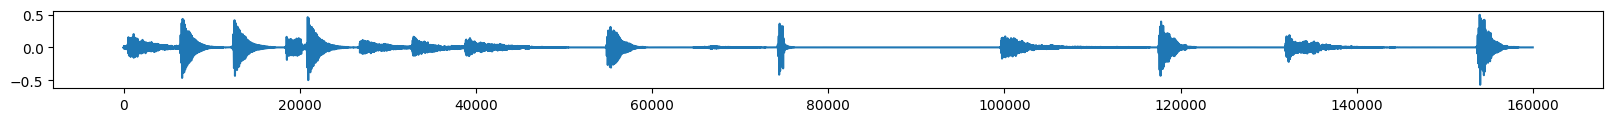

Saved checkpoint at epoch 180
Finished epoch number 180 with a total of 10000 debug_seqs
 time: 2025-09-05 17:44:35.446434, epoch 181,  Loss: 0.0199
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


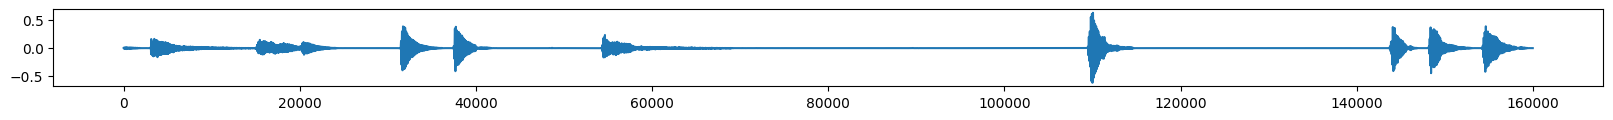

Finished epoch number 181 with a total of 10000 debug_seqs
 time: 2025-09-05 17:44:57.031951, epoch 182,  Loss: 0.0206
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


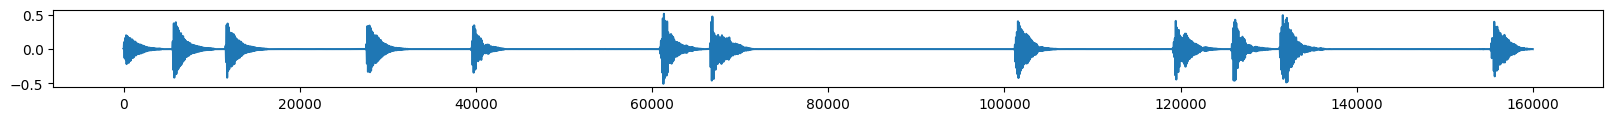

Finished epoch number 182 with a total of 10000 debug_seqs
 time: 2025-09-05 17:45:18.563435, epoch 183,  Loss: 0.0196
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


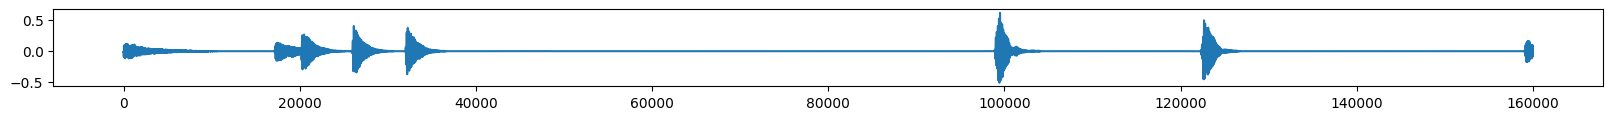

Finished epoch number 183 with a total of 10000 debug_seqs
 time: 2025-09-05 17:45:40.126258, epoch 184,  Loss: 0.0195
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


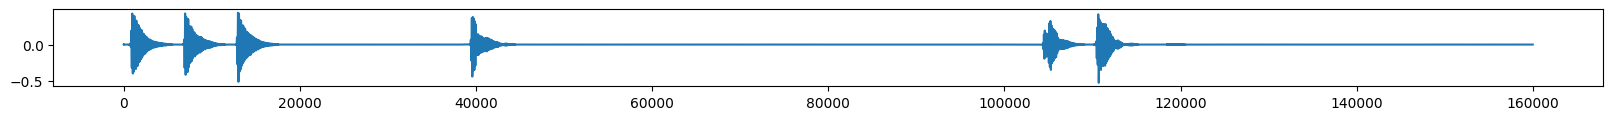

Finished epoch number 184 with a total of 10000 debug_seqs
 time: 2025-09-05 17:46:01.731325, epoch 185,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


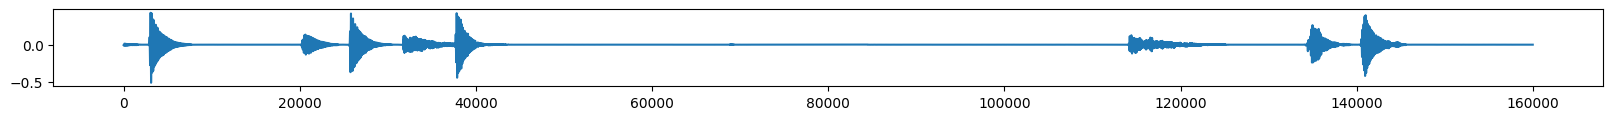

Finished epoch number 185 with a total of 10000 debug_seqs
 time: 2025-09-05 17:46:23.264022, epoch 186,  Loss: 0.0193
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


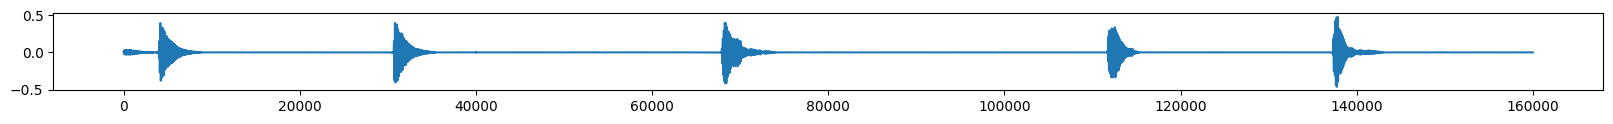

Finished epoch number 186 with a total of 10000 debug_seqs
 time: 2025-09-05 17:46:44.787083, epoch 187,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


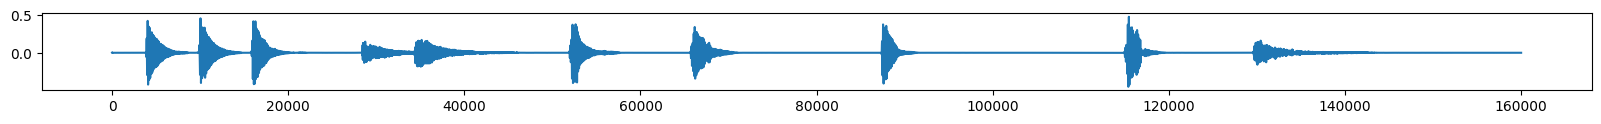

Finished epoch number 187 with a total of 10000 debug_seqs
 time: 2025-09-05 17:47:06.291843, epoch 188,  Loss: 0.0192
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


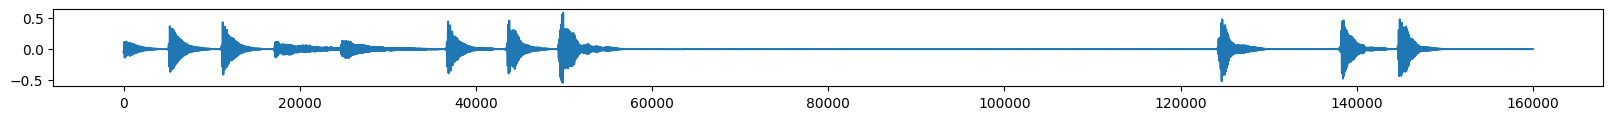

Finished epoch number 188 with a total of 10000 debug_seqs
 time: 2025-09-05 17:47:27.819559, epoch 189,  Loss: 0.0193
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


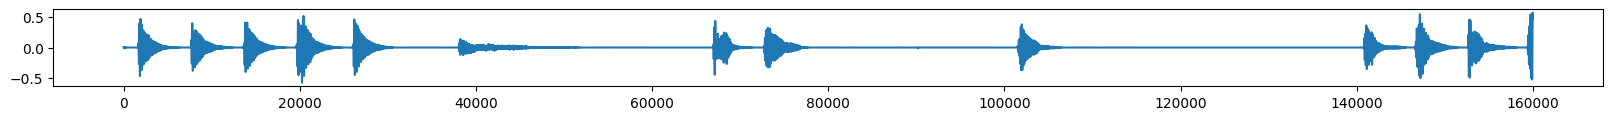

Finished epoch number 189 with a total of 10000 debug_seqs
 time: 2025-09-05 17:47:49.445224, epoch 190,  Loss: 0.0201
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


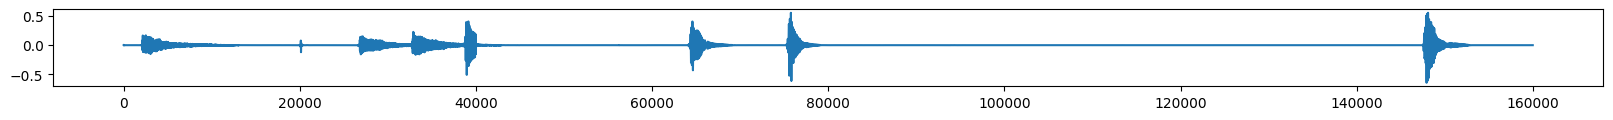

Saved checkpoint at epoch 190
Finished epoch number 190 with a total of 10000 debug_seqs
 time: 2025-09-05 17:48:11.014222, epoch 191,  Loss: 0.0198
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.91. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


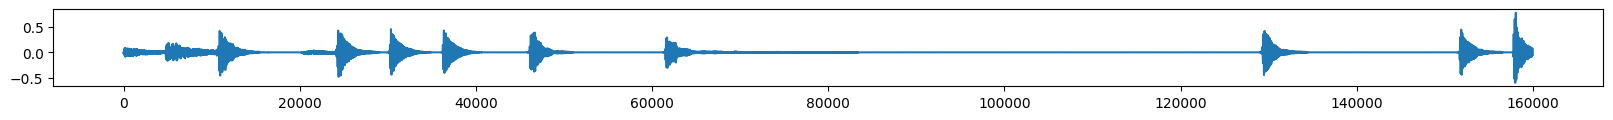

Finished epoch number 191 with a total of 10000 debug_seqs
 time: 2025-09-05 17:48:32.595321, epoch 192,  Loss: 0.0194
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


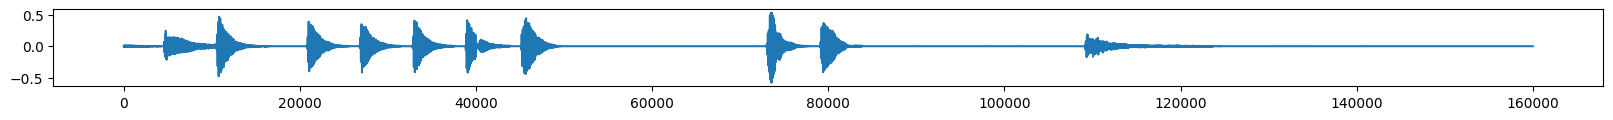

Finished epoch number 192 with a total of 10000 debug_seqs
 time: 2025-09-05 17:48:54.151506, epoch 193,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


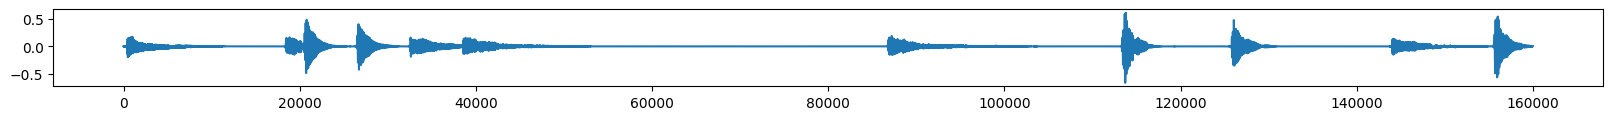

Finished epoch number 193 with a total of 10000 debug_seqs
 time: 2025-09-05 17:49:15.773839, epoch 194,  Loss: 0.0195
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


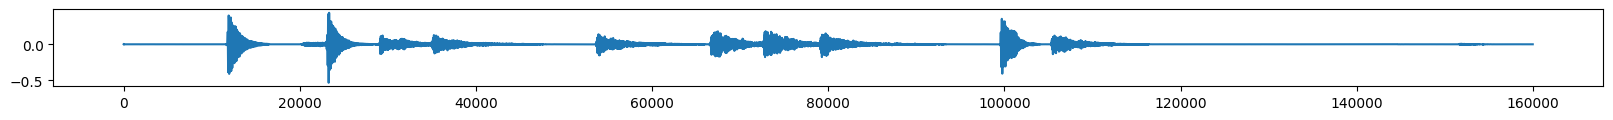

Finished epoch number 194 with a total of 10000 debug_seqs
 time: 2025-09-05 17:49:37.314597, epoch 195,  Loss: 0.0195
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


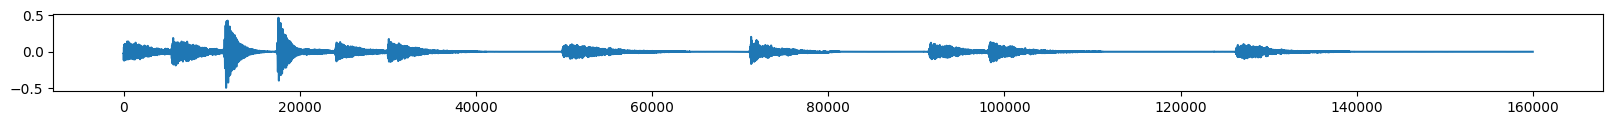

Finished epoch number 195 with a total of 10000 debug_seqs
 time: 2025-09-05 17:49:58.847800, epoch 196,  Loss: 0.0200
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


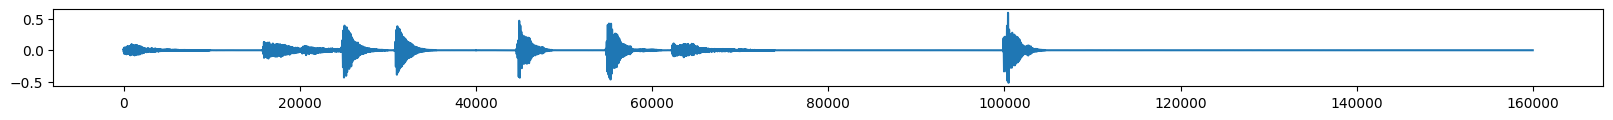

Finished epoch number 196 with a total of 10000 debug_seqs
 time: 2025-09-05 17:50:20.435123, epoch 197,  Loss: 0.0189
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


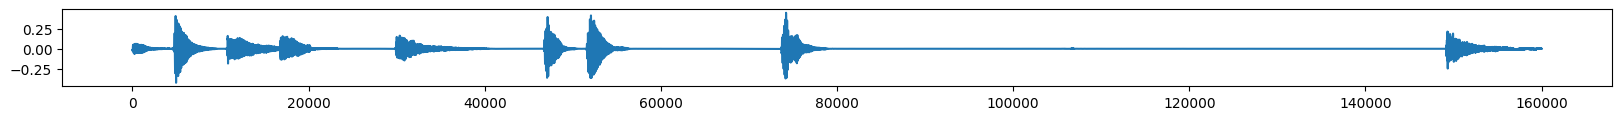

Finished epoch number 197 with a total of 10000 debug_seqs
 time: 2025-09-05 17:50:41.933744, epoch 198,  Loss: 0.0191
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


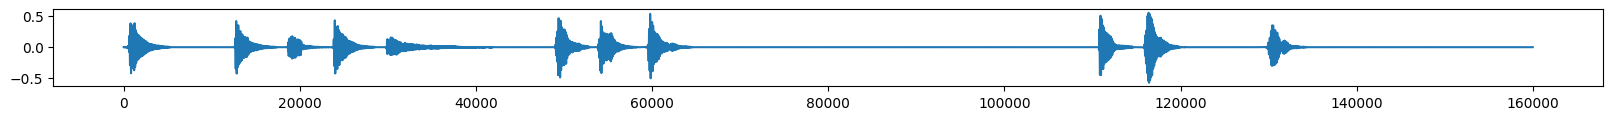

Finished epoch number 198 with a total of 10000 debug_seqs
 time: 2025-09-05 17:51:03.604821, epoch 199,  Loss: 0.0196
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.90. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


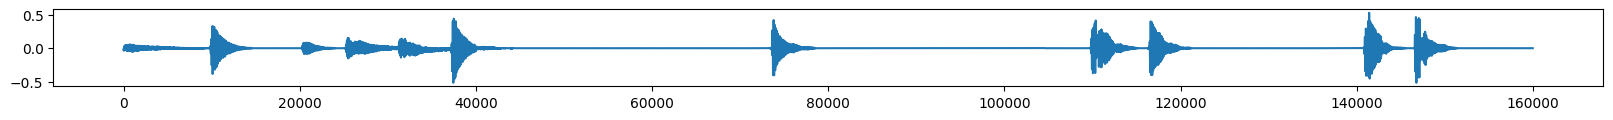

Finished epoch number 199 with a total of 10000 debug_seqs
 time: 2025-09-05 17:51:25.309700, epoch 200,  Loss: 0.0203
About to call inference with p_inp.shape = torch.Size([1, 125, 129]), x.shape = torch.Size([125, 128]), and c.shape = torch.Size([375, 1])
About to call inference with p_inp.device = cpu, x.device = cpu, and c.device = cpu
Starting latent inference... with codebook_size=1024, n_q=8, cond_size=1
Warming up model hidden state with provided latents...
Generating 375 latent frames...
Latent generation complete. RNN time to generate: 0.89. Converting to audio...
Inference complete - encoding time = 0.02.
plot the audio which has shape (160000,)


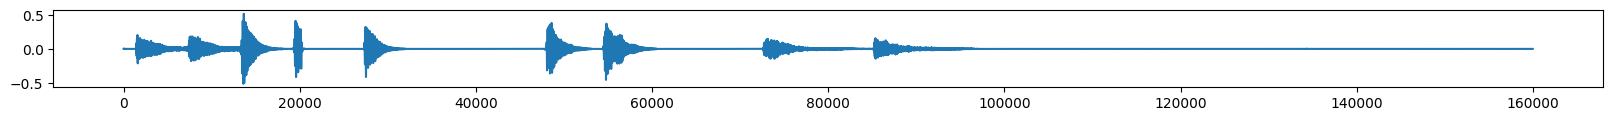

Saved checkpoint at epoch 200
Training time taken: 1:11:42
Saved checkpoint at epoch 200


'/home/lonce/working/RNN4Codecs/output/20250905_163943_encodectest_TokWotalDuet_splitseqs_sl125_nodes64_6l_size96_nq8/checkpoints/last_checkpoint.pt'

In [14]:
# Train!
#*************************************
enc_model.to(device)
list_of_losses = []

print('{:%Y-%m-%d %H:%M:%S} Starting training...'.format(datetime.now()))
start_time = time.monotonic()
#-------------------------------------------------------------------------------
for epoch in range(start_epoch, start_epoch+params['num_epochs']):
    train(rnn,epoch)
#-------------------------------------------------------------------------------
writer.close()
elapsed_time = time.monotonic() - start_time
print('Training time taken:',time_taken(elapsed_time))

#Just make sure the final model gets saved
checkpoint_data = {
    'epoch': epoch+1,
    'model_state_dict': rnn.state_dict(),
    'optimizer_state_dict': optimizer.state_dict()
}
# Save numbered checkpoint
numbered_path = os.path.join(f"{out_dir}/checkpoints", f"checkpoint_{epoch+1}.pt")
torch.save(checkpoint_data, numbered_path)
print(f"Saved checkpoint at epoch {epoch+1}")
# Copy to "last" (much faster than saving twice)
last_path = os.path.join(f"{out_dir}/checkpoints", "last_checkpoint.pt")
shutil.copy2(numbered_path, last_path)


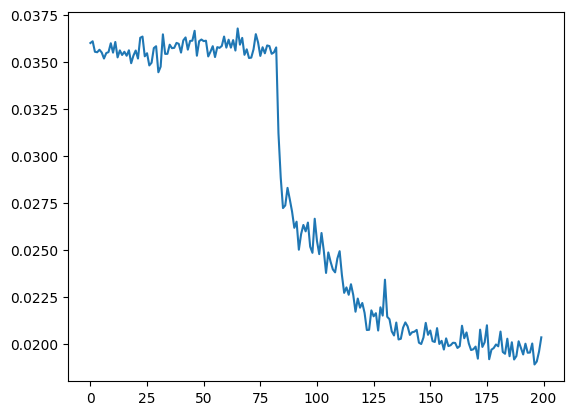

In [15]:
# Plot the loss over time
#*************************************
plt.figure()
plt.plot(list_of_losses)
plt.show()  # This will actually display the plot

In [16]:
list_of_losses

[0.0359964714050293,
 0.03608955383300781,
 0.035531959533691405,
 0.0355057487487793,
 0.03563914108276367,
 0.03549143981933594,
 0.035172065734863284,
 0.03546255111694336,
 0.03551384353637695,
 0.03598489761352539,
 0.03548461532592773,
 0.03605352020263672,
 0.03523226547241211,
 0.03560429000854492,
 0.03536058044433594,
 0.03553167343139649,
 0.03531991195678711,
 0.035610763549804685,
 0.034922988891601565,
 0.03532895278930664,
 0.03559809112548828,
 0.03517044067382812,
 0.03627634429931641,
 0.03633980178833008,
 0.03528971481323242,
 0.03545423889160156,
 0.0348048210144043,
 0.034948501586914066,
 0.03572842788696289,
 0.03582569122314453,
 0.03444113540649414,
 0.03473880386352539,
 0.036458221435546875,
 0.035417449951171874,
 0.03542196655273438,
 0.03590773773193359,
 0.03572277069091797,
 0.035740318298339846,
 0.036003448486328124,
 0.03595303726196289,
 0.035487415313720704,
 0.03613594055175781,
 0.03629387283325195,
 0.035643798828125,
 0.036107139587402345,
 0.0